# Bayesian modelling of chocolate quality rating
#### Authors: Julia Wiktorowicz, Patrycja Wybranowska

In [107]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
from cmdstanpy import CmdStanModel
import arviz as az
import matplotlib
import matplotlib.colors as mcolors

RELATIVE = False


## Introduction
The global chocolate market constitutes a highly valuable sector of the food industry, with its revenue amounting to $146.8 billion in 2026 [1]. According to HTF Market Intelligence, the Global Fine or Flavor Cocoa market is expected to grow by 8.4% by 2033 [2], the key market driver being the rising customer consciousness regarding health benefits of eating high-quality dark chocolate [3]. In sensory evaluation the chocolate quality is determined by the experts by complex flavor profiles. Recent research has emphasized the importance of geographical origin as a determinant of cocoa quality, influencing its flavor and consumer perception. In particular, the review [4] highlights the growing interest in understanding and quantifying the relationship between cocoa origin and quality-related attributes.

Inspired by this work, our project investigates whether information available on commercial chocolate products, including cocoa beans and producers' country of origin, can be used to explain differences in chocolate ratings. The model could be potentially used for chocolate producers and distributors to benchmark their products against global standards or to help retailers and customers to make better-informed choices by highlighting the regional factors that drive chocolate quality.

The dataset utilized in this project is sourced from the Manhattan Chocolate Society's [Flavors of Cacao database](https://flavorsofcacao.com/chocolate_database.html). It contains over 2500 expert reviews of chocolate bars, icluding details about cocoa bean source, producent's country of origin and basic informations about chocolate ingredients. The target variable is Rating, an expert quality score ranging from 1.0 (unpalatable) to 5.0 (outstanding). For this study, we analyzed data spanning the 2016–2026 range, ensuring a complete dataset with no missing values.

## Data preprocessing
The raw data from Flavors of Cacao database contains information about producer and its origin country, country and details of bean origin, basic ingredients, most memorable characteristics, final rating and date of the review.

In [108]:
columns = [
    'REF', 'Company', 'Company Location', 'Review Date', 
    'Country of Bean Origin', 'Specific Bean Origin', 
    'Cocoa Percent', 'Ingredients', 'Most Memorable Characteristics', 'Rating'
]

df_pre = pd.read_csv('data/data.txt', sep='\t', names=columns, skiprows=1) if RELATIVE else pd.read_csv('/workspace/project2/Chocolate-DA/data/data.txt', sep='\t', names=columns, skiprows=1)
df_pre.head()

,REF,Company,Company Location,Review Date,Country of Bean Origin,Specific Bean Origin,Cocoa Percent,Ingredients,Most Memorable Characteristics,Rating
0,3016,Cacao Store,Japan,2026,Thailand,Chumphon,70%,"3- B,S,C","light apricot, pear, nutty, clean",3.25
1,3016,Cacao Store,Japan,2026,Taiwan,Fu-Wan,70%,"3- B,S,C","cocoa,roasty,pungent, chemical",2.75
2,3016,Cacao Store,Japan,2026,Madagascar,Ambanja,75%,"3- B,S,C","high acid, atypical honey",3.00
3,3016,URA,Peru,2026,Peru,"Piura, Chulucanas, Finca Tito Jimenez",70%,"3- B,S,C","grapes, roast (smoke like)",3.75
4,3020,URA,Peru,2026,Peru,"VRAEM 99, Pichari, Cusco, Finca Daria",70%,"3- B,S,C",plum,3.50


We discarded variables irrelevant to our analysis, including reference numbers, memorable characteristics and specific company details. The geographic identifiers were standarized manually. We corrected spelling mistakes and unified naming conventions by merging specific sub-regions into their respective countries (e.g., Sulawesi and Sumatra were aggregated under Indonesia). Distinct territories, such as Puerto Rico, were retained as separate entities. We also removed entries where 'Country of Bean Origin' was specified as 'Blend', since it represents a mixture of cocoa form multiple undisclosed sources.

We excluded categories (both 'Country of Bean Origin' and 'Company Location') with fewer than 10 observations to prevent noisy parameter estimates and provide sufficient information for posterior distribution.

All categorical country names were converted into integer indices, as required by the Stan to define hierarchical grouping factors. Additionally, a rating index was assigned to each row, which is necessary for proper indexing within the ordered logistic likelihood.

'Cocoa Percantage' variable was converted to float and transformed using the logit function to map it onto an infinite real scale. The resulting values were then standardized (centered around zero and divided by their standard deviation) to produce the final 'logit_cocoa_scaled' variable. This approach allowed for optimal convergence during MCMC sampling. 

Lastly, we created a binary feature 'has_vanilla', allowing the model to explicitly isolate and quantify the impact of vanilla additions on the overall rating.

In [109]:
df = pd.read_csv('data/chocolate_data_preprocessed.csv') if RELATIVE else pd.read_csv('/workspace/project2/Chocolate-DA/data/chocolate_data_preprocessed.csv')

all_possible_ratings = [round(1.0 + 0.25 * i, 2) for i in range(17)]
rating_map     = {val: i + 1 for i, val in enumerate(all_possible_ratings)}
inv_rating_map = {v: k for k, v in rating_map.items()}

df['rating_id'] = df['Rating'].map(rating_map)
C = 17
J = df['Bean Origin ID'].max()
K = df['Company Location ID'].max()
df.drop(['Year Norm'], axis='columns')

df['cocoa_prop'] = df['Cocoa Percent'].str.replace('%', '').astype(float) / 100.0
df['cocoa_prop'] = df['cocoa_prop'].clip(0.01, 0.99)
df['logit_cocoa'] = np.log(df['cocoa_prop'] / (1 - df['cocoa_prop']))
df['logit_cocoa_scaled'] = (
    (df['logit_cocoa'] - df['logit_cocoa'].mean()) / df['logit_cocoa'].std()
)

df['has_vanilla'] = df['Has vanilla'].astype(int)

df = df[['Company Location', 'Review Date', 'Country of Bean Origin',
       'Cocoa Percent', 'Rating', 'Bean Origin ID', 'Company Location ID', 'rating_id', 'logit_cocoa_scaled', 'has_vanilla']]

df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1076 entries, 0 to 1075
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Company Location        1076 non-null   object 
 1   Review Date             1076 non-null   int64  
 2   Country of Bean Origin  1076 non-null   object 
 3   Cocoa Percent           1076 non-null   object 
 4   Rating                  1076 non-null   float64
 5   Bean Origin ID          1076 non-null   int64  
 6   Company Location ID     1076 non-null   int64  
 7   rating_id               1076 non-null   int64  
 8   logit_cocoa_scaled      1076 non-null   float64
 9   has_vanilla             1076 non-null   int64  
dtypes: float64(2), int64(5), object(3)
memory usage: 84.2+ KB


,Company Location,Review Date,Country of Bean Origin,Cocoa Percent,Rating,Bean Origin ID,Company Location ID,rating_id,logit_cocoa_scaled,has_vanilla
0,Japan,2026,Madagascar,75%,3.00,15,11,9,0.894445,0
1,Peru,2026,Peru,70%,3.75,18,15,12,-0.417679,0
2,Peru,2026,Peru,70%,3.50,18,15,11,-0.417679,0
3,U.K.,2026,Philippines,70%,3.50,19,19,11,-0.417679,0
4,Canada,2026,Peru,80%,3.25,18,5,10,2.396446,0


# Model 1
![dag-model1.png](attachment:dag-model1.png)

Each chocolate bar receives a rating driven by two geographic factors: bean origin and producer location. The producer location directly impacts quality through specific manufacturing cultures, distinct technologies and regional standards. Furthermore, company location dictates the country of bean origin through established supply chains, historical trade relations and producers choice between fine-flavor or bulk cocoa [4]. The bean origin affects the rating directly because unique climate, soil and local post-harvest treatments directly imapct taste of cocoa [3].


$$y_i \sim \text{OrderedLogistic}(\phi_i,c), \qquad
\phi_i = \mu + \alpha_{j[i]} + \gamma_{k[i]}$$

$$\alpha_j \sim \text{Normal}(0, \sigma_{\text{origin}}), \qquad
\gamma_k \sim \text{Normal}(0, \sigma_{\text{producer}})$$



$\mu$ is the global average quality. $\alpha_{j[i]}$ and $\gamma_{k[i]}$ are deviations attributable to bean origin $j$ and producer country $k$ respectively. The cutpoints $c = (c_1, \ldots, c_{17})$ patrition the axis into 17 observed ratings (1-5 with 0.25 step).


### Priors
Since we did not find any specific values based on literature, we chose weakly informative priors that let the data determine the parameter values guarding against implausible ones.

$\mu \sim \text{Normal}(0, 1)$ - centered at zero with a scale of 1 log-odds unit, reflecting no prior expectation about whether bars rate high or low on average, while preventing the global baseline from taking extreme values.

$\sigma_{\text{origin}},\ \sigma_{\text{producer}} \sim \text{HalfNormal}(1)$ - controls between-group variation. Scale of 1 places 95% of prior mass below $\approx 2.0$ log-odds, allowing meaningful country-level differences while ruling out implausible extremes where one country dominates all others.

$c_k \sim \text{Normal}(0, 2.5)$ - weakly informative prior on the log-odds scale. This scale was chosen empirically via prior predictive check: it produces a prior predictive rating distribution close to uniform across all 17 categories (1–5 in 0.25 steps), reflecting no prior assumption about which rating is more likely.

<style>
.small-code pre {
    font-size: 12px;
}
</style>

<div class="small-code">

```stan
data {
  int<lower=1> N;
  int<lower=1> J;
  int<lower=1> K;
  int<lower=1> C;
  array[N] int<lower=1, upper=J> origin;
  array[N] int<lower=1, upper=K> producer;
}

generated quantities {
  vector[C - 1] c;
  {
    vector[C - 1] c_raw;
    for (k in 1:(C - 1))
      c_raw[k] = normal_rng(0, 2.5);
    c = sort_asc(c_raw);
  }

  real mu_global      = normal_rng(0, 1);
  real sigma_origin   = abs(normal_rng(0, 1));
  real sigma_producer = abs(normal_rng(0, 1));

  vector[J] alpha;
  for (j in 1:J)
    alpha[j] = normal_rng(0, sigma_origin);

  vector[K] gamma;
  for (k in 1:K)
    gamma[k] = normal_rng(0, sigma_producer);

  array[N] int rating_pred;
  for (i in 1:N) {
    real phi_i = mu_global + alpha[origin[i]] + gamma[producer[i]];
    rating_pred[i] = ordered_logistic_rng(phi_i, c);
  }
}
```

### Prior predictive check

In [110]:
prior_model1 = CmdStanModel(stan_file="prior_model1-new.stan") if RELATIVE else CmdStanModel(stan_file="/workspace/project2/Chocolate-DA/prior_model1-new.stan") 

prior_data1 = {
    "N": len(df),
    "J": J,
    "K": K,
    "C": C,
    "origin":   df['Bean Origin ID'].tolist(),
    "producer": df['Company Location ID'].tolist(),
}

prior_fit1 = prior_model1.sample(
    data=prior_data1,
    fixed_param=True,
    iter_sampling=2000,
    chains=1,
    seed=42,
    show_progress=False,
)

rating_pred_prior1  = prior_fit1.stan_variable("rating_pred")
a_prior_draws1      = prior_fit1.stan_variable("alpha")
b_prior_draws1      = prior_fit1.stan_variable("gamma")
mu_global_prior1    = prior_fit1.stan_variable("mu_global")
sigma_origin_prior1 = prior_fit1.stan_variable("sigma_origin")
sigma_prod_prior1   = prior_fit1.stan_variable("sigma_producer")
alpha_prior1        = prior_fit1.stan_variable("alpha")
gamma_prior1        = prior_fit1.stan_variable("gamma")
c_prior_draws       = prior_fit1.stan_variable("c")

07:19:44 - cmdstanpy - INFO - CmdStan start processing
07:19:44 - cmdstanpy - INFO - Chain [1] start processing
07:19:46 - cmdstanpy - INFO - Chain [1] done processing


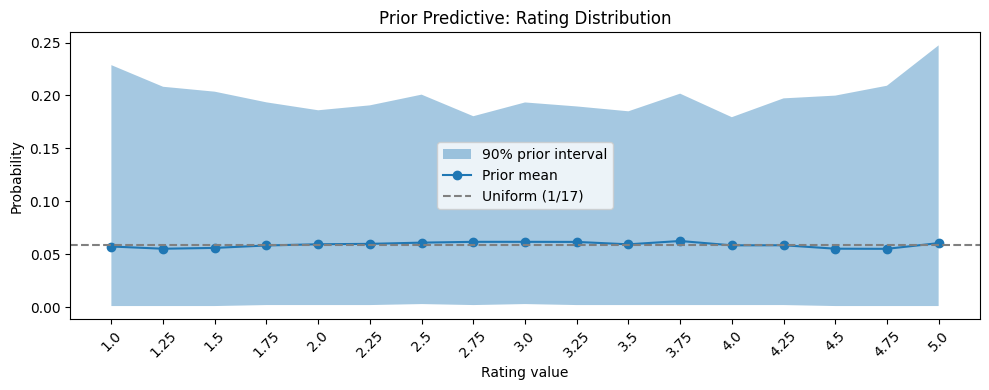

In [111]:
fig, ax = plt.subplots(figsize=(10, 4))
pred_counts = np.apply_along_axis(
    lambda x: np.bincount(x.astype(int) - 1, minlength=C), 1, rating_pred_prior1
)
pred_probs = pred_counts / pred_counts.sum(axis=1, keepdims=True)

ax.fill_between(range(1, C+1),
                np.percentile(pred_probs, 5,  axis=0),
                np.percentile(pred_probs, 95, axis=0),
                alpha=0.4, label="90% prior interval")
ax.plot(range(1, C+1), pred_probs.mean(axis=0), marker='o', label="Prior mean")
ax.axhline(1/C, ls='--', color='gray', label=f"Uniform (1/{C})")
ax.set_xlabel("Rating value")
ax.set_ylabel("Probability")
ax.set_title("Prior Predictive: Rating Distribution")
ax.set_xticks(range(1, C+1))
ax.set_xticklabels([str(inv_rating_map[i]) for i in range(1, C+1)], rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

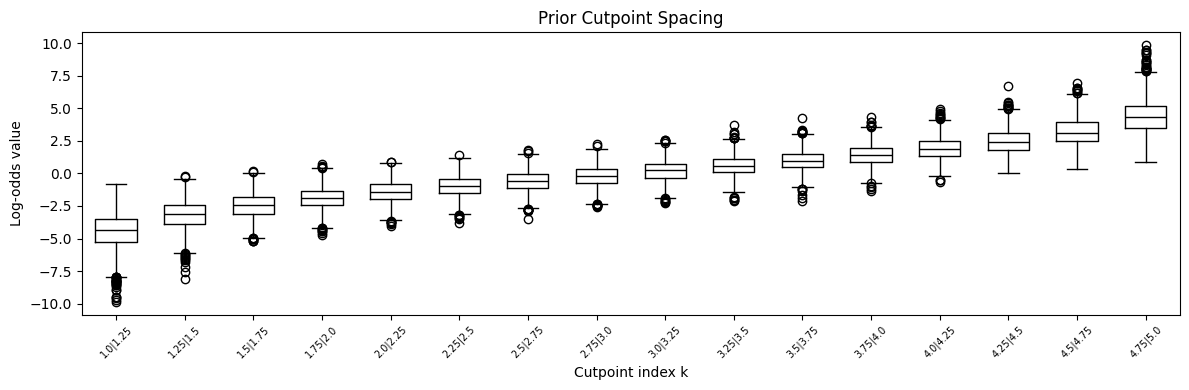

In [112]:
fig, ax = plt.subplots(figsize=(12, 4))
for k in range(C - 1):
    ax.boxplot(c_prior_draws[:, k], positions=[k+1], widths=0.6,
               medianprops=dict(color='black'))
ax.set_xlabel("Cutpoint index k")
ax.set_ylabel("Log-odds value")
ax.set_title("Prior Cutpoint Spacing")
ax.set_xticks(range(1, C))
ax.set_xticklabels(
    [f"{inv_rating_map[i]}|{inv_rating_map[i+1]}" for i in range(1, C)],
    rotation=45, fontsize=7
)
plt.tight_layout()
plt.show()

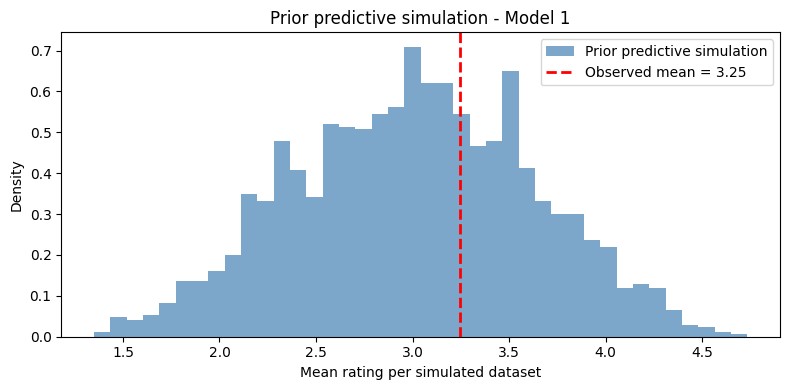

In [113]:
id_to_rating = np.vectorize(inv_rating_map.get)
rating_pred_values = id_to_rating(rating_pred_prior1)

prior_draw_means1 = rating_pred_values.mean(axis=1)
observed_mean = df["Rating"].mean()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(prior_draw_means1, bins=40, density=True, alpha=0.7,
        color="steelblue", label="Prior predictive simulation")
ax.axvline(observed_mean, color="red", lw=2, ls="--",
           label=f"Observed mean = {observed_mean:.2f}")
ax.set_xlabel("Mean rating per simulated dataset")
ax.set_ylabel("Density")
ax.set_title("Prior predictive simulation - Model 1")
ax.legend()
plt.tight_layout()
plt.show()

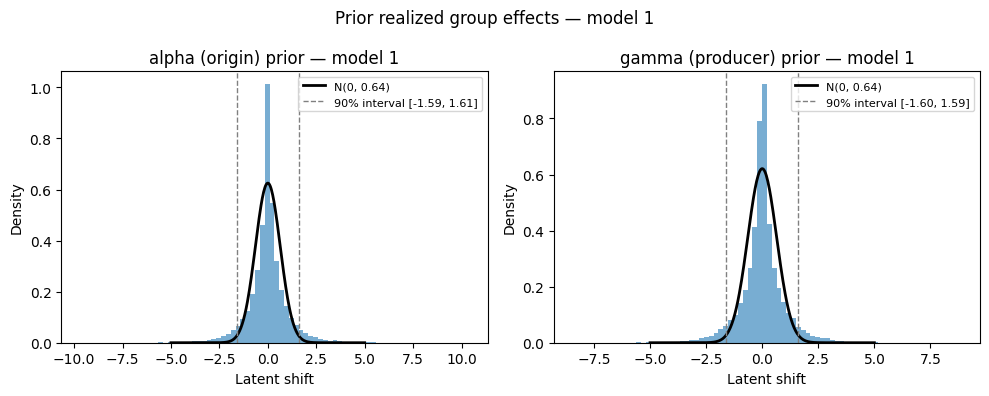

In [124]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
x = np.linspace(-5, 5, 300)

for ax, draws, name in zip(
    axes,
    [alpha_prior1, gamma_prior1],
    ["alpha (origin)", "gamma (producer)"]
):
    med_sigma = np.median(draws.std(axis=1))
    ax.hist(draws.flatten(), bins=80, density=True, alpha=0.6)
    ax.plot(x, stats.norm.pdf(x, 0, med_sigma), 'k-', lw=2,
            label=f"N(0, {med_sigma:.2f})")
    ax.axvline(np.percentile(draws.flatten(), 5),  color='gray', ls='--', lw=1)
    ax.axvline(np.percentile(draws.flatten(), 95), color='gray', ls='--', lw=1,
               label=f"90% interval [{np.percentile(draws.flatten(),5):.2f}, "
                     f"{np.percentile(draws.flatten(),95):.2f}]")
    ax.set_title(f"{name} prior — model 1")
    ax.set_xlabel("Latent shift")
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)

plt.suptitle("Prior realized group effects — model 1")
plt.tight_layout()
plt.show()

The prior predictive checks confirm that the chosen priors are weakly informative: the expected rating distribution is uniform across all 17 categories, cutpoints are correctly ordered and span the full rating range, and the observed mean rating falls comfortably within the prior predictive distribution without being specifically anticipated by it.

### Posterior Analysis

<style>
.small-code pre {
    font-size: 12px;
}
</style>

<div class="small-code">

```stan
data {
  int<lower=1> N;
  int<lower=1> J;
  int<lower=1> K;
  int<lower=1> C;

  array[N] int<lower=1, upper=J> origin;
  array[N] int<lower=1, upper=K> producer;
  array[N] int<lower=1, upper=C> rating;
}

parameters {
  ordered[C - 1] c;
  real mu_global;

  real<lower=0> sigma_origin;
  real<lower=0> sigma_producer;

  vector[J] alpha_raw;
  vector[K] gamma_raw;
}

transformed parameters {
  vector[J] alpha = alpha_raw * sigma_origin;
  vector[K] gamma = gamma_raw * sigma_producer;
}

model {
  mu_global      ~ normal(0, 1);
  sigma_origin   ~ normal(0, 1);
  sigma_producer ~ normal(0, 1);

  alpha_raw ~ std_normal();
  gamma_raw ~ std_normal();

  c ~ normal(0, 2.5);

  vector[N] phi;
  for (i in 1:N)
    phi[i] = mu_global + alpha[origin[i]] + gamma[producer[i]];

  rating ~ ordered_logistic(phi, c);
}

generated quantities {
  array[N] int rating_pred;
  vector[N] log_lik;
  for (i in 1:N) {
    real phi_i = mu_global + alpha[origin[i]] + gamma[producer[i]];
    rating_pred[i] = ordered_logistic_rng(phi_i, c);
    log_lik[i]     = ordered_logistic_lpmf(rating[i] | phi_i, c);
  }
}

```

In [114]:
model_1_fit = CmdStanModel(stan_file="model_1-new.stan") if RELATIVE else CmdStanModel(stan_file="/workspace/project2/Chocolate-DA/model_1-new.stan")

data_sim1 = {
    "N": len(df),
    "J": J,
    "K": K,
    "C": C,                          
    "origin":   df['Bean Origin ID'].tolist(),
    "producer": df['Company Location ID'].tolist(),
    "rating":   df['rating_id'].tolist(),
}

fit1 = model_1_fit.sample(
    data=data_sim1,
    chains=4,
    iter_warmup=2000,
    iter_sampling=1000,
    adapt_delta=0.99,
    max_treedepth=15,
    seed=42,
    show_progress=True,
)

07:19:49 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

07:25:14 - cmdstanpy - INFO - CmdStan done processing.
07:25:14 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: ordered_logistic: Cut-points is not a valid ordered vector. The element at 2 is -556.56, but should be greater than the previous element, -556.56 (in 'model_1-new.stan', line 42, column 2 to column 36)
	Exception: ordered_logistic: Cut-points is not a valid ordered vector. The element at 2 is -555.173, but should be greater than the previous element, -555.173 (in 'model_1-new.stan', line 42, column 2 to column 36)
	Exception: ordered_logistic: Cut-points is not a valid ordered vector. The element at 3 is -138.134, but should be greater than the previous element, -138.134 (in 'model_1-new.stan', line 42, column 2 to column 36)
	Exception: ordered_logistic: Cut-points is not a valid ordered vector. The element at 3 is -33.3333, but should be greater than the previous element, -33.3333 (in 'model_1-new.stan', line 42, column 2 to column 36)
	Exception: ordere

Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.



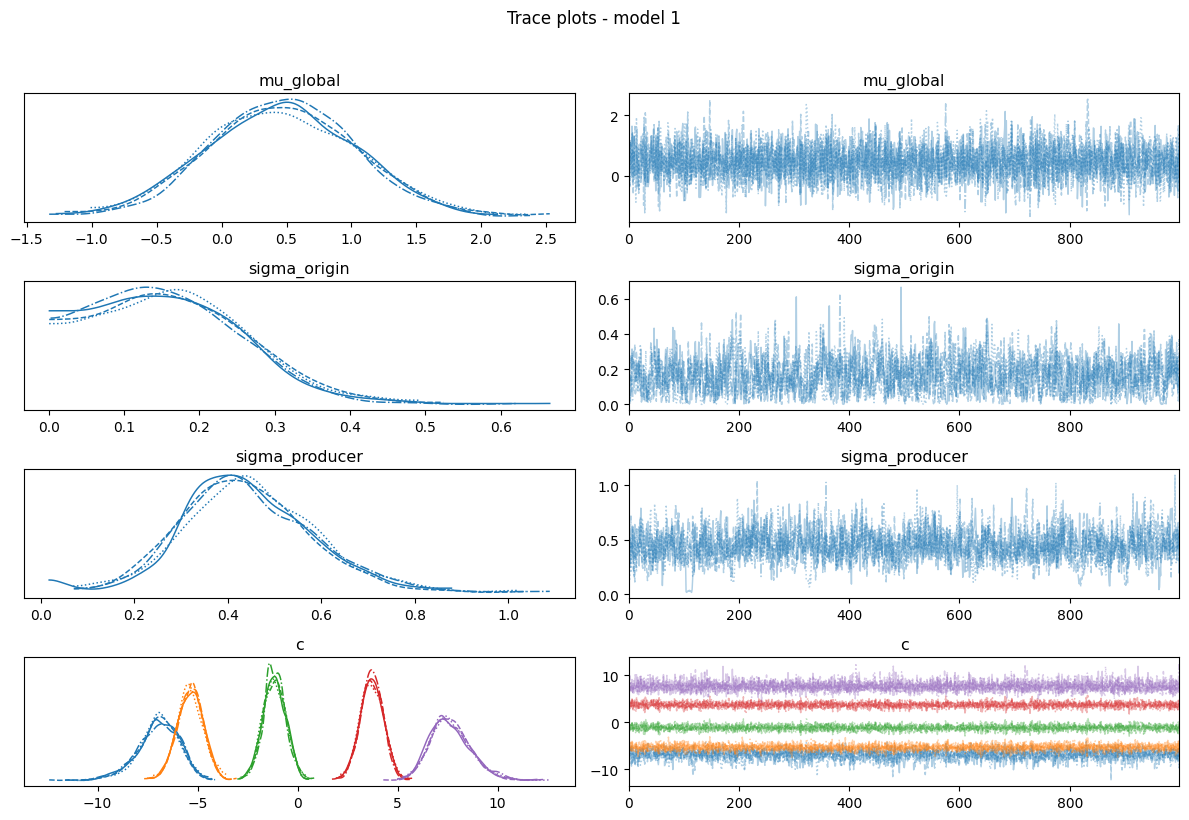

In [115]:

rating_pred_post1  = fit1.stan_variable("rating_pred")
alpha_samples1     = fit1.stan_variable("alpha")
gamma_samples1     = fit1.stan_variable("gamma")
sigma_origin1      = fit1.stan_variable("sigma_origin")
sigma_producer1    = fit1.stan_variable("sigma_producer")
mu_global_samples1 = fit1.stan_variable("mu_global")
c_samples1         = fit1.stan_variable("c")

id_to_rating     = np.vectorize(inv_rating_map.get)
rating_pred_vals = id_to_rating(rating_pred_post1)

id_to_rating     = np.vectorize(inv_rating_map.get)
rating_pred_vals = id_to_rating(rating_pred_post1)


print(fit1.diagnose())
idata1 = az.from_cmdstanpy(fit1)

# az.plot_trace(idata1, var_names=["mu_global", "sigma_origin",
#                                   "sigma_producer"])
az.plot_trace(idata1, var_names=["mu_global", "sigma_origin", "sigma_producer",
                                  "c"],
              coords={"c_dim_0": [0, 3, 7, 11, 15]})
plt.suptitle("Trace plots - model 1", y=1.02)
plt.tight_layout()
plt.show()


id_to_rating    = np.vectorize(inv_rating_map.get)
pred_values     = id_to_rating(rating_pred_post1)

pred_counts = np.apply_along_axis(
    lambda x: np.bincount(x.astype(int) - 1, minlength=C),
    1, rating_pred_post1
)
pred_probs = pred_counts / pred_counts.sum(axis=1, keepdims=True)

obs_counts = np.bincount(df['rating_id'].values.astype(int) - 1, minlength=C)
obs_probs  = obs_counts / obs_counts.sum()


Non-fatal warnings occured at the start of the warmup phase but they did not affect the validity of the final posterior draws. The MCMC sampling process was completed successfully with no problems detected. The E-BFMI as well as R_hat and ESS for all parameters were satisfactory. 

Trace plots show fuzzy caterpillar traces indication satisfactory convergence for all parameters. The five selected cutpoints $(c_1, c_4, c_8, c_{12}, c_{16})$ show well-separated posteriors with good chain mixing. Cutpoints corresponding to the observed rating range (2.25–4) are sharply identified by the data, while the extreme cutpoints $c_1$ and $c_{16}$ show wider posteriors reflecting that they are primarily defined by prior.

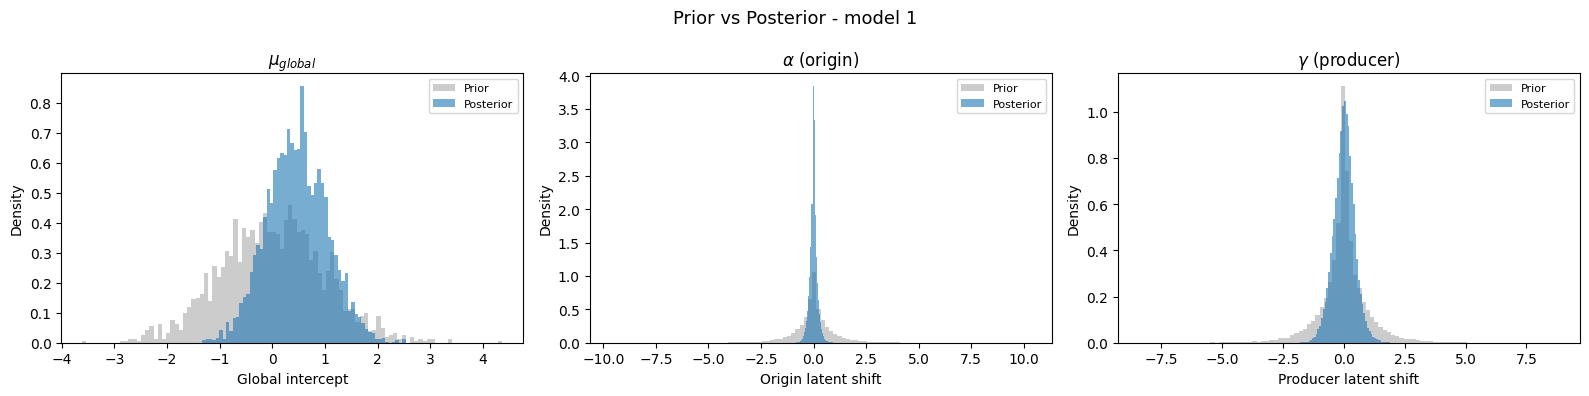

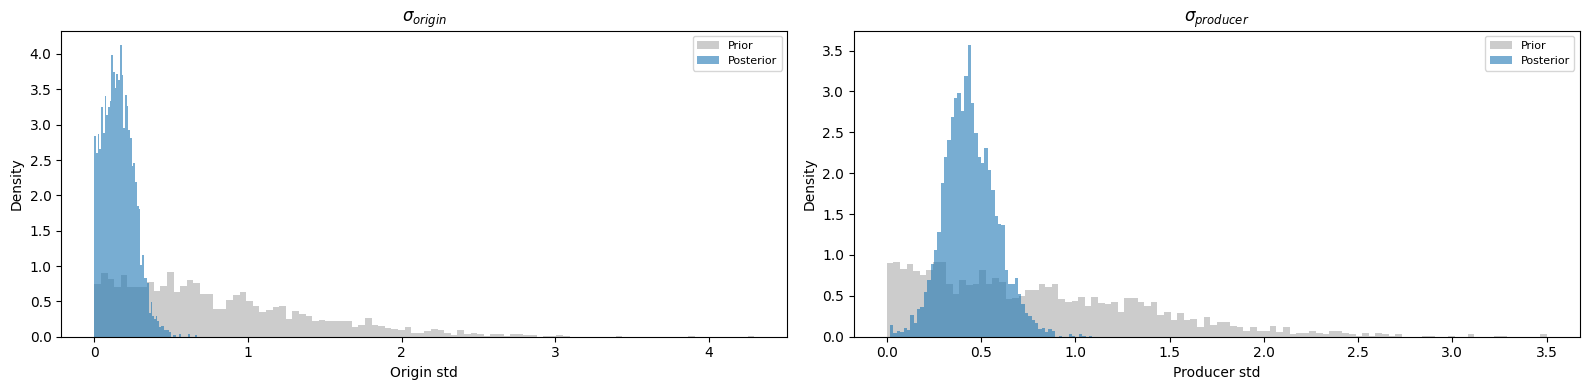

In [116]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes = axes.flatten()

panels = [
    (mu_global_samples1,       mu_global_prior1,        r"$\mu_{global}$",        "Global intercept"),
    (alpha_samples1.flatten(), alpha_prior1.flatten(),   r"$\alpha$ (origin)",     "Origin latent shift"),
    (gamma_samples1.flatten(), gamma_prior1.flatten(),   r"$\gamma$ (producer)",   "Producer latent shift")
]

for ax, (post, prior, title, xlabel) in zip(axes, panels):
    ax.hist(prior, bins=100, density=True, alpha=0.4, color="gray", label="Prior")
    ax.hist(post,  bins=60,  density=True, alpha=0.6, label="Posterior")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)

plt.suptitle("Prior vs Posterior - model 1", fontsize=13)
plt.tight_layout()

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
axes = axes.flatten()

panels = [
    (sigma_origin1,            sigma_origin_prior1,      r"$\sigma_{origin}$",     "Origin std"),
    (sigma_producer1,          sigma_prod_prior1,        r"$\sigma_{producer}$",   "Producer std")   
]

for ax, (post, prior, title, xlabel) in zip(axes, panels):
    ax.hist(prior, bins=100, density=True, alpha=0.4, color="gray", label="Prior")
    ax.hist(post,  bins=60,  density=True, alpha=0.6, label="Posterior")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

$\mu_{global}$ is clearly narrowed and concentrated around 0.5. $\alpha$ and $\gamma$ posterior is much tighter than prior, strongly concentrated around zero, with producer effect having more spread than origin. Producer std is bigger than origin std suggesting producers tend to vary more.

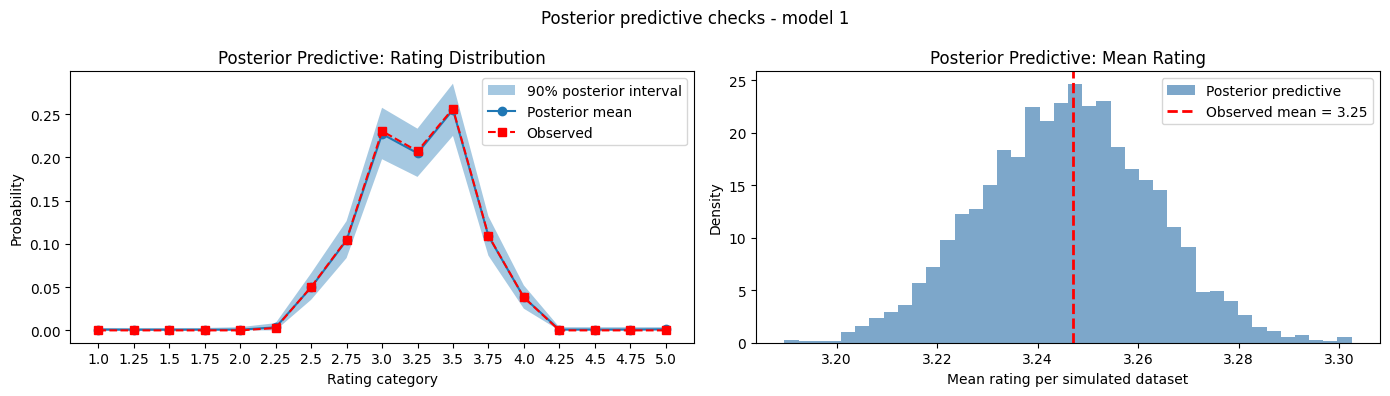

In [117]:
pred_counts = np.apply_along_axis(
    lambda x: np.bincount(x.astype(int) - 1, minlength=C), 1, rating_pred_post1
)
pred_probs = pred_counts / pred_counts.sum(axis=1, keepdims=True)
obs_counts = np.bincount(df['rating_id'].values.astype(int) - 1, minlength=C)
obs_probs  = obs_counts / obs_counts.sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.fill_between(
    range(1, C + 1),
    np.percentile(pred_probs, 5,  axis=0),
    np.percentile(pred_probs, 95, axis=0),
    alpha=0.4, label="90% posterior interval"
)
ax.plot(range(1, C + 1), pred_probs.mean(axis=0), marker='o', label="Posterior mean")
ax.plot(range(1, C + 1), obs_probs, marker='s',
        color='red', ls='--', label="Observed")
ax.set_xlabel("Rating category")
ax.set_ylabel("Probability")
ax.set_title("Posterior Predictive: Rating Distribution")
ax.set_xticks(range(1, C+1))
xticks = [inv_rating_map[i+1] for i in range(C)]
ax.set_xticklabels(xticks)
ax.legend()

ax = axes[1]
ax.hist(rating_pred_vals.mean(axis=1), bins=40, density=True, alpha=0.7,
        color="steelblue", label="Posterior predictive")
ax.axvline(df["Rating"].mean(), color="red", lw=2, ls="--",
           label=f"Observed mean = {df['Rating'].mean():.2f}")
ax.set_xlabel("Mean rating per simulated dataset")
ax.set_ylabel("Density")
ax.set_title("Posterior Predictive: Mean Rating")
ax.legend()

plt.suptitle("Posterior predictive checks - model 1")
plt.tight_layout()
plt.show()

The posterior mean tracks the observed distribution well. The red observed line sits on top of the blue posterior mean across all categories. The 90% interval is narrow, indicating the model is well-calibrated. Unobserved categories (below 2.25 and above 4.0) correctly receive near-zero probability. The observed mean (3.25) falls near the center of the posterior predictive distribution.

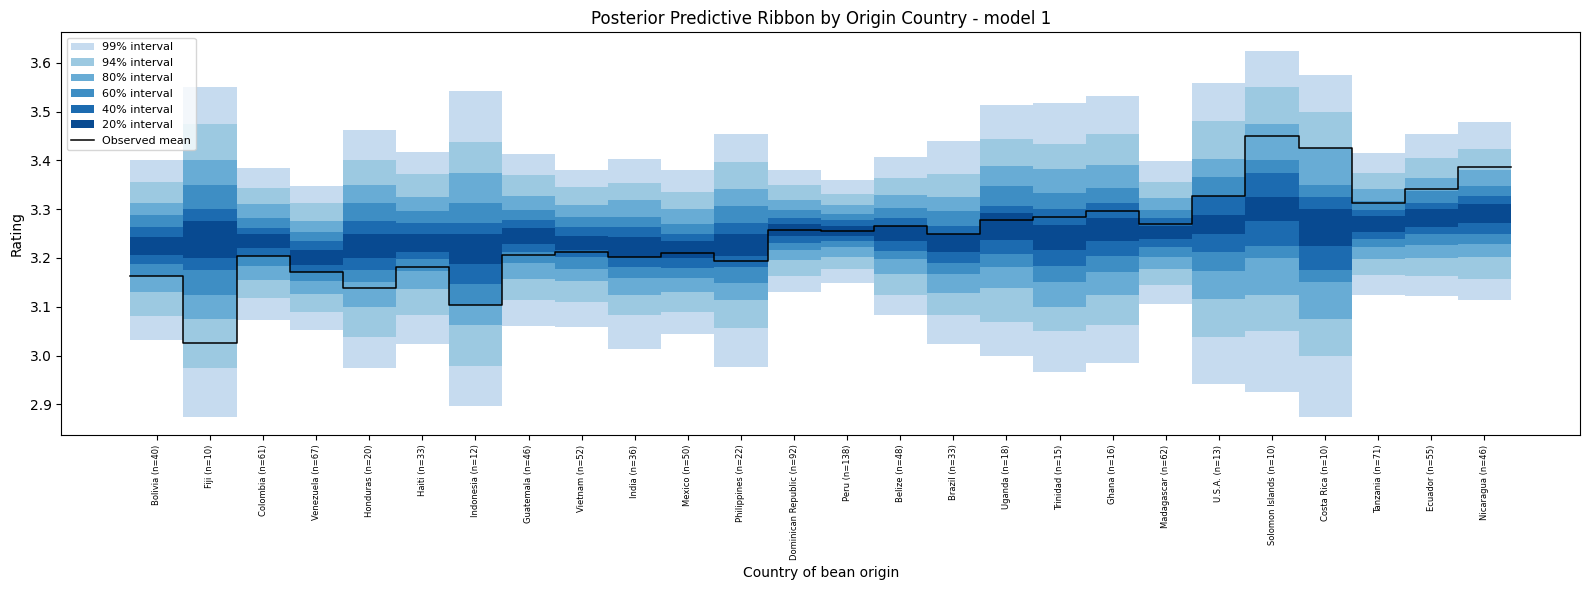

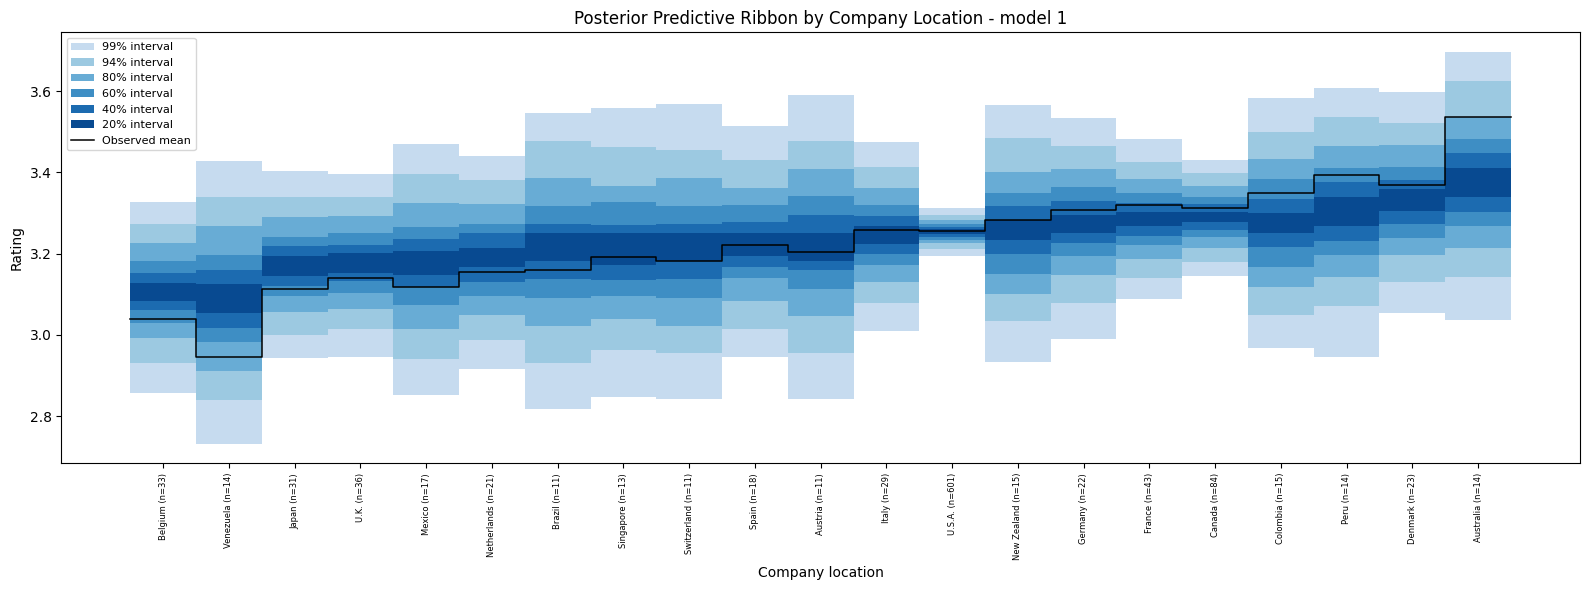

In [118]:
mu_origin_total1 = mu_global_samples1[:, None] + alpha_samples1

current_df = df.copy().reset_index(drop=True)
countries   = sorted(current_df["Country of Bean Origin"].unique())
country_idx = {c: i + 1 for i, c in enumerate(countries)}
current_df["country_id"] = current_df["Country of Bean Origin"].map(country_idx)
counts_origin = current_df["Country of Bean Origin"].value_counts().to_dict()

results11 = pd.DataFrame({
    "country":     countries,
    "mu_mean":     mu_origin_total1.mean(axis=0),
    "mu_lower_94": np.percentile(mu_origin_total1, 3,  axis=0),
    "mu_upper_94": np.percentile(mu_origin_total1, 97, axis=0),
    "n_bars":      [counts_origin.get(c, 0) for c in countries],
}).sort_values("mu_mean", ascending=True).reset_index(drop=True)

observed_per_country1 = current_df.groupby("country_id")["Rating"].mean()
obs_sorted_origin = results11["country"].map(
    lambda c: observed_per_country1[country_idx[c]]
).values

J_sorted1 = len(results11)
x2        = np.arange(1, J_sorted1 + 1)
num_draws = rating_pred_vals.shape[0]

post_pred_means_origin = np.zeros((num_draws, J_sorted1))
for i, country_name in enumerate(results11["country"]):
    idx = current_df[current_df["Country of Bean Origin"] == country_name].index.values
    post_pred_means_origin[:, i] = rating_pred_vals[:, idx].mean(axis=1)

def step_edges(values, x):
    edges   = np.concatenate([x - 0.5, x[-1:] + 0.5])
    stepped = np.concatenate([[values[0]], values])
    return edges, stepped

levels = [99, 94, 80, 60, 40, 20]
cmap   = matplotlib.colormaps["Blues"]
colors = [mcolors.to_hex(cmap(f)) for f in np.linspace(0.25, 0.9, len(levels))]

fig, ax = plt.subplots(figsize=(16, 6))
for lev, color in zip(levels, colors):
    lo = np.percentile(post_pred_means_origin, (100 - lev) / 2,       axis=0)
    hi = np.percentile(post_pred_means_origin, 100 - (100 - lev) / 2, axis=0)
    e, ls = step_edges(lo, x2); _, hs = step_edges(hi, x2)
    ax.fill_between(e, ls, hs, step="pre", color=color,
                    linewidth=0, label=f"{lev}% interval")

e, os = step_edges(obs_sorted_origin, x2)
ax.step(e, os, where="pre", color="black", linewidth=1.1, label="Observed mean")
ax.set_xticks(x2)
ax.set_xticklabels(
    [f"{r['country']} (n={r['n_bars']})" for _, r in results11.iterrows()],
    rotation=90, fontsize=6
)
ax.set_xlabel("Country of bean origin"); ax.set_ylabel("Rating")
ax.set_title("Posterior Predictive Ribbon by Origin Country - model 1")
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

# ======================================================================
mu_company_total1 = mu_global_samples1[:, None] + gamma_samples1

company_locations = sorted(current_df["Company Location"].unique())
company_idx       = {c: i + 1 for i, c in enumerate(company_locations)}
current_df["company_id"] = current_df["Company Location"].map(company_idx)
counts_company = current_df["Company Location"].value_counts().to_dict()

results12 = pd.DataFrame({
    "company":     company_locations,
    "mu_mean":     mu_company_total1.mean(axis=0),
    "mu_lower_94": np.percentile(mu_company_total1, 3,  axis=0),
    "mu_upper_94": np.percentile(mu_company_total1, 97, axis=0),
    "n_bars":      [counts_company.get(c, 0) for c in company_locations],
}).sort_values("mu_mean", ascending=True).reset_index(drop=True)

observed_per_company1 = current_df.groupby("company_id")["Rating"].mean()
obs_sorted_company = results12["company"].map(
    lambda c: observed_per_company1[company_idx[c]]
).values

K_sorted = len(results12)
x3       = np.arange(1, K_sorted + 1)

post_pred_means_company = np.zeros((num_draws, K_sorted))
for i, comp_name in enumerate(results12["company"]):
    idx = current_df[current_df["Company Location"] == comp_name].index.values
    post_pred_means_company[:, i] = rating_pred_vals[:, idx].mean(axis=1)

fig, ax = plt.subplots(figsize=(16, 6))
for lev, color in zip(levels, colors):
    lo = np.percentile(post_pred_means_company, (100 - lev) / 2,       axis=0)
    hi = np.percentile(post_pred_means_company, 100 - (100 - lev) / 2, axis=0)
    e, ls = step_edges(lo, x3); _, hs = step_edges(hi, x3)
    ax.fill_between(e, ls, hs, step="pre", color=color,
                    linewidth=0, label=f"{lev}% interval")

e, cs = step_edges(obs_sorted_company, x3)
ax.step(e, cs, where="pre", color="black", linewidth=1.1, label="Observed mean")
ax.set_xticks(x3)
ax.set_xticklabels(
    [f"{r['company']} (n={r['n_bars']})" for _, r in results12.iterrows()],
    rotation=90, fontsize=6
)
ax.set_xlabel("Company location"); ax.set_ylabel("Rating")
ax.set_title("Posterior Predictive Ribbon by Company Location - model 1")
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

Observed means fall within posterior intervals for all groups. Origin ribbon shows wider intervals for countries with smaller amount of entries (Solomon Islands, Costa Rica), narrower for large (U.S.A, Peru). Partial pooling is working correctly by shrinking estimates for smaller groups toward the global mean 3.25.

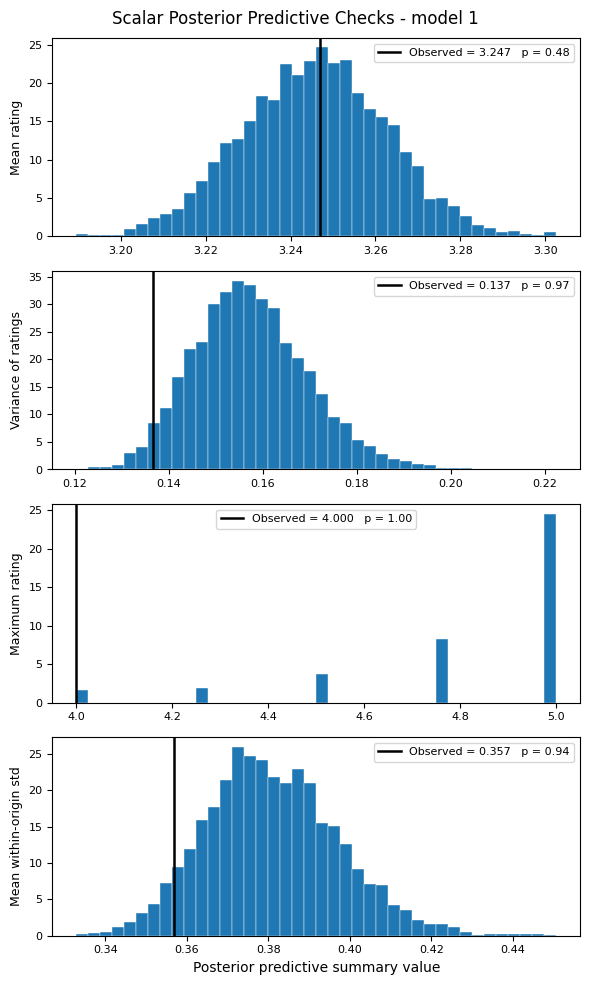

In [119]:
obs     = df["Rating"].values
y_rep   = rating_pred_vals 

rep_mean = y_rep.mean(axis=1)
rep_var  = y_rep.var(axis=1)
rep_max  = y_rep.max(axis=1)

# within-country std
country_sds_rep = np.zeros((num_draws, J_sorted1))
country_sds_obs = np.zeros(J_sorted1)
for i, country_name in enumerate(results11["country"]):
    idx = current_df[current_df["Country of Bean Origin"] == country_name].index.values
    if len(idx) > 1:
        country_sds_rep[:, i] = y_rep[:, idx].std(axis=1)
        country_sds_obs[i]    = obs[idx].std()
mean_country_sd_rep = country_sds_rep.mean(axis=1)
mean_country_sd_obs = country_sds_obs.mean()

# within-company std
company_sds_rep = np.zeros((num_draws, K_sorted))
company_sds_obs = np.zeros(K_sorted)
for i, comp_name in enumerate(results12["company"]):
    idx = current_df[current_df["Company Location"] == comp_name].index.values
    if len(idx) > 1:
        company_sds_rep[:, i] = y_rep[:, idx].std(axis=1)
        company_sds_obs[i]    = obs[idx].std()
mean_company_sd_rep = company_sds_rep.mean(axis=1)
mean_company_sd_obs = company_sds_obs.mean()

checks = [
    (rep_mean,           obs.mean(),          "Mean rating"),
    (rep_var,            obs.var(),           "Variance of ratings"),
    (rep_max,            obs.max(),           "Maximum rating"),
    (mean_country_sd_rep, mean_country_sd_obs, "Mean within-origin std"),
    (mean_company_sd_rep, mean_company_sd_obs, "Mean within-company std"),
]

fig, axes = plt.subplots(4, 1, figsize=(6, 10))
for ax, (rep_stat, obs_stat, ylabel) in zip(axes, checks):
    ax.hist(rep_stat, bins=40, density=True, edgecolor="white", linewidth=0.3)
    p_val = np.mean(rep_stat >= obs_stat)
    ax.axvline(obs_stat, color="k", linewidth=1.8,
               label=f"Observed = {obs_stat:.3f}   p = {p_val:.2f}")
    ax.set_ylabel(ylabel, fontsize=9)
    ax.legend(fontsize=8)
    ax.tick_params(labelsize=8)

axes[-1].set_xlabel("Posterior predictive summary value", fontsize=10)
plt.suptitle("Scalar Posterior Predictive Checks - model 1", fontsize=12)
plt.tight_layout()
plt.show()

The scalar checks reveal that the model overestimates within-group variance at both the origin and producer country level, suggesting that country-level grouping is too coarse to fully capture the variability structure in the data. Individual producers within the same country differ in quality, which is a distinction the model cannot represent given singe effect per country. Model could be extended by adding individual producer random effect, though this is difficult to justify with only 1076 observations spread across 429 unique producers (roughly 2.5 observations per producer on average).

# Model 2

![dag-model2.png](attachment:dag-model2.png)

Model 2 extends Model 1 by adding two bar-level recipe predictors:logit-transformed cocoa percentage and vanilla presence. Research suggests that cocoa concentration directly influences perceived flavor intensity and bitterness [6], while vanilla is commonly used in mass-produced chocolate to mask unpleasant flavors of lower-quality cocoa [5]. Since all ratings come from a single American expert panel, both effects are modeled as global fixed coefficients rather than varying by producer country - the data cannot reliably distinguish genuine market-specific preferences from reviewer bias.

$$y_i \sim \text{OrderedLogistic}(\phi_i, c), \qquad
\phi_i = \mu + \alpha_{j[i]} + \gamma_{k[i]}
+ \beta_{\text{cocoa}} \cdot \text{cocoa\_logit}_i
+ \beta_{\text{vanilla}} \cdot \mathbb{1}[\text{vanilla}_i]$$

$$\alpha_j \sim \text{Normal}(0, \sigma_{\text{origin}}), \qquad
\gamma_k \sim \text{Normal}(0, \sigma_{\text{producer}})$$


### Priors
All hierarchical parameters share identical priors with Model 1.The two new coefficients use weakly informative priors reflectingno prior assumption about the direction of their effects.

$\beta_{\text{cocoa}},\ \beta_{\text{vanilla}} \sim \text{Normal}(0, 1)$ - allows effects of up to $\approx 2$ log-odds units while remaining agnostic about whether higher cocoa% or vanilla presence improves or worsens ratings.

<style>
.small-code pre {
    font-size: 12px;
}
</style>

<div class="small-code">

```stan
data {
  int<lower=1> N;
  int<lower=1> J;
  int<lower=1> K;
  int<lower=1> C;
  array[N] int<lower=1, upper=J> origin;
  array[N] int<lower=1, upper=K> producer;
  vector[N] cocoa_logit;
  array[N] int<lower=0, upper=1> has_vanilla;
}

generated quantities {
  vector[C - 1] c;
  {
    vector[C - 1] c_raw;
    for (k in 1:(C - 1)) c_raw[k] = normal_rng(0, 2.5);
    c = sort_asc(c_raw);
  }

  real mu_global      = normal_rng(0, 1);
  real sigma_origin   = abs(normal_rng(0, 1));
  real sigma_producer = abs(normal_rng(0, 1));
  real beta_cocoa     = normal_rng(0, 1);
  real beta_vanilla   = normal_rng(0, 1);

  vector[J] alpha;
  for (j in 1:J)
    alpha[j] = normal_rng(0, sigma_origin);

  vector[K] gamma;
  for (k in 1:K)
    gamma[k] = normal_rng(0, sigma_producer);

  array[N] int rating_pred;
  for (i in 1:N) {
    real phi_i = mu_global
                 + alpha[origin[i]]
                 + gamma[producer[i]]
                 + beta_cocoa * cocoa_logit[i]
                 + beta_vanilla * has_vanilla[i];
    rating_pred[i] = ordered_logistic_rng(phi_i, c);
  }
}
```

In [ ]:
prior_model2 = CmdStanModel(stan_file="prior_model2-new_nocon.stan") if RELATIVE else CmdStanModel(stan_file="/workspace/project2/Chocolate-DA/prior_model2-new_nocon.stan")
# prior_model2 = CmdStanModel(stan_file="prior_model2-new.stan")

prior_data2 = {
    "N": len(df),
    "J": J,
    "K": K,
    "C": C,
    "origin":          df['Bean Origin ID'].tolist(),
    "producer":        df['Company Location ID'].tolist(),
    # "origin_location": origin_location,
    "cocoa_logit":     df['logit_cocoa_scaled'].tolist(),
    "has_vanilla":     df['has_vanilla'].tolist(),
}

prior_fit2 = prior_model2.sample(
    data=prior_data2,
    fixed_param=True,
    iter_sampling=2000,
    chains=1,
    seed=42,
    show_progress=False,
)

# pull prior samples
rating_pred_prior2   = prior_fit2.stan_variable("rating_pred")
mu_global_prior2     = prior_fit2.stan_variable("mu_global")
sigma_origin_prior2  = prior_fit2.stan_variable("sigma_origin")
sigma_prod_prior2    = prior_fit2.stan_variable("sigma_producer")
alpha_prior2         = prior_fit2.stan_variable("alpha")
gamma_prior2         = prior_fit2.stan_variable("gamma")
c_prior_draws2       = prior_fit2.stan_variable("c")
beta_cocoa_prior2    = prior_fit2.stan_variable("beta_cocoa")
beta_vanilla_prior2  = prior_fit2.stan_variable("beta_vanilla")


06:37:11 - cmdstanpy - INFO - CmdStan start processing
06:37:11 - cmdstanpy - INFO - Chain [1] start processing
06:37:17 - cmdstanpy - INFO - Chain [1] done processing


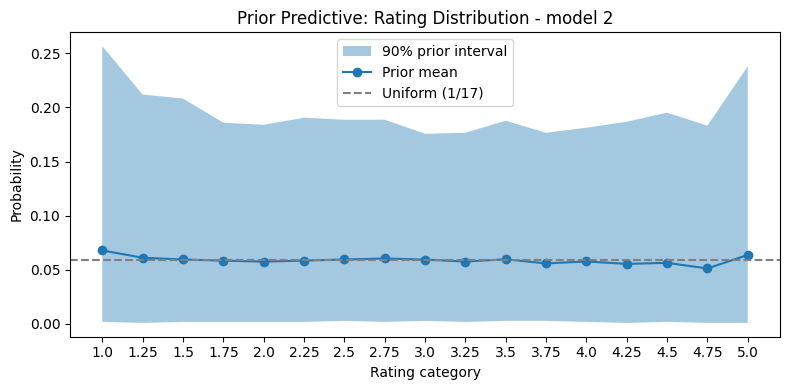

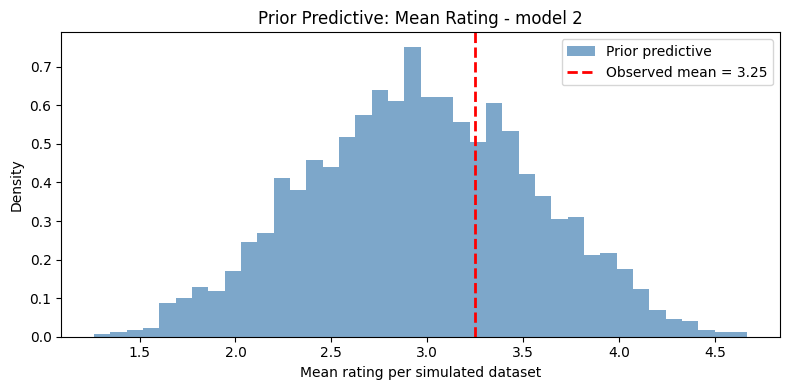

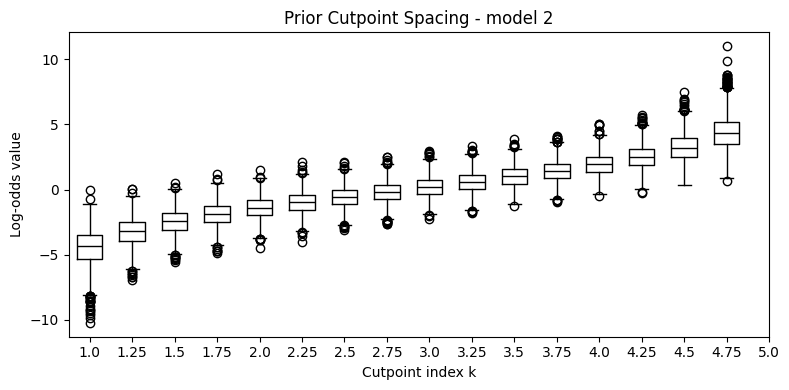

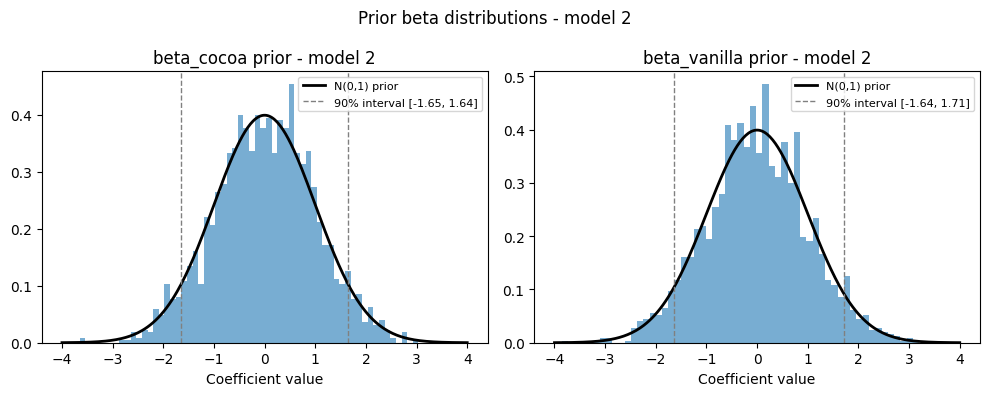

In [101]:
pred_counts_p2 = np.apply_along_axis(
    lambda x: np.bincount(x.astype(int) - 1, minlength=C), 1, rating_pred_prior2
)
pred_probs_p2 = pred_counts_p2 / pred_counts_p2.sum(axis=1, keepdims=True)

# fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# ax = axes[0]
# rating distrib ===============
fig, ax = plt.subplots(figsize=(8, 4))
ax.fill_between(range(1, C + 1),
                np.percentile(pred_probs_p2, 5,  axis=0),
                np.percentile(pred_probs_p2, 95, axis=0),
                alpha=0.4, label="90% prior interval")
ax.plot(range(1, C + 1), pred_probs_p2.mean(axis=0), marker='o', label="Prior mean")
ax.axhline(1 / C, ls='--', color='gray', label=f"Uniform (1/{C})")
ax.set_xlabel("Rating category"); ax.set_ylabel("Probability")
ax.set_title("Prior Predictive: Rating Distribution - model 2")
xticks = all_possible_ratings
ax.set_xticks(range(1, C+1))
ax.set_xticklabels(xticks)
plt.tight_layout()
ax.legend()
plt.show()

# mean rating ======================
id_to_rating = np.vectorize(inv_rating_map.get)
prior2_vals  = id_to_rating(rating_pred_prior2)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(prior2_vals.mean(axis=1), bins=40, density=True, alpha=0.7,
        color="steelblue", label="Prior predictive")
ax.axvline(df["Rating"].mean(), color="red", lw=2, ls="--",
           label=f"Observed mean = {df['Rating'].mean():.2f}")
ax.set_xlabel("Mean rating per simulated dataset")
ax.set_ylabel("Density")
ax.set_title("Prior Predictive: Mean Rating - model 2")
ax.legend()
plt.tight_layout()
plt.show()

# ── Prior cutpoint spacing ────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
for k in range(C - 1):
    ax.boxplot(c_prior_draws2[:, k], positions=[k + 1], widths=0.6,
               medianprops=dict(color='black'))
ax.set_xlabel("Cutpoint index k")
ax.set_ylabel("Log-odds value")
ax.set_title("Prior Cutpoint Spacing - model 2")
xticks = all_possible_ratings
ax.set_xticks(range(1, C+1))
ax.set_xticklabels(xticks)
plt.tight_layout()
plt.show()

# Prior distributions ============================
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
x_b = np.linspace(-4, 4, 300)

for ax, samples, name in zip(
    axes,
    [beta_cocoa_prior2, beta_vanilla_prior2],
    ["beta_cocoa", "beta_vanilla"]
):
    ax.hist(samples, bins=60, density=True, alpha=0.6)
    ax.plot(x_b, stats.norm.pdf(x_b, 0, 1), 'k-', lw=2, label="N(0,1) prior")
    ax.axvline(np.percentile(samples, 5),  color='gray', ls='--', lw=1)
    ax.axvline(np.percentile(samples, 95), color='gray', ls='--', lw=1,
               label=f"90% interval [{np.percentile(samples,5):.2f}, {np.percentile(samples,95):.2f}]")
    ax.set_title(f"{name} prior - model 2")
    ax.set_xlabel("Coefficient value"); ax.legend(fontsize=8)

plt.suptitle("Prior beta distributions - model 2")
plt.tight_layout()
plt.show()

Prior predictive checks for Model 2 confirm that adding cocoa% and vanilla predictors does not alter the approximately uniform rating distribution established in Model 1. The new beta priors are symmetric around zero with 90% mass within $\pm 1.65$ log-odds, reflecting no prior assumption.

### Posterior analysis

<style>
.small-code pre {
    font-size: 12px;
}
</style>

<div class="small-code">

```stan
data {
  int<lower=1> N;
  int<lower=1> J;
  int<lower=1> K;
  int<lower=1> C;

  array[N] int<lower=1, upper=J> origin;
  array[N] int<lower=1, upper=K> producer;
  array[N] int<lower=1, upper=C> rating;

  vector[N] cocoa_logit;
  array[N] int<lower=0, upper=1> has_vanilla;
}

parameters {
  ordered[C - 1] c;
  real mu_global;

  real<lower=0> sigma_origin;
  real<lower=0> sigma_producer;

  vector[J] alpha_raw;
  vector[K] gamma_raw;

  real beta_cocoa;
  real beta_vanilla;
}

transformed parameters {
  vector[J] alpha = alpha_raw * sigma_origin;
  vector[K] gamma = gamma_raw * sigma_producer;
}

model {
  mu_global      ~ normal(0, 1);
  sigma_origin   ~ normal(0, 1);
  sigma_producer ~ normal(0, 1);

  alpha_raw ~ std_normal();
  gamma_raw ~ std_normal();

  c ~ normal(0, 2.5);

  beta_cocoa   ~ normal(0, 1);
  beta_vanilla ~ normal(0, 1);

  vector[N] phi;
  for (i in 1:N)
    phi[i] = mu_global
             + alpha[origin[i]]
             + gamma[producer[i]]
             + beta_cocoa * cocoa_logit[i]
             + beta_vanilla * has_vanilla[i];

  rating ~ ordered_logistic(phi, c);
}

generated quantities {
  array[N] int rating_pred;
  vector[N] log_lik;
  for (i in 1:N) {
    real phi_i = mu_global
                 + alpha[origin[i]]
                 + gamma[producer[i]]
                 + beta_cocoa * cocoa_logit[i]
                 + beta_vanilla * has_vanilla[i];
    rating_pred[i] = ordered_logistic_rng(phi_i, c);
    log_lik[i]     = ordered_logistic_lpmf(rating[i] | phi_i, c);
  }
}
```

In [100]:
model_2_fit = CmdStanModel(stan_file="model_2-new_nocon.stan") if RELATIVE else CmdStanModel(stan_file="/workspace/project2/Chocolate-DA/model_2-new_nocon.stan")
# model_2_fit = CmdStanModel(stan_file="model_2-new.stan")

data_sim2 = {
    "N": len(df),
    "J": J,
    "K": K,
    "C": C,
    "origin":          df['Bean Origin ID'].tolist(),
    "producer":        df['Company Location ID'].tolist(),
    "rating":          df['rating_id'].tolist(),
    "cocoa_logit":     df['logit_cocoa_scaled'].tolist(),
    "has_vanilla":     df['has_vanilla'].tolist(),
}

fit2 = model_2_fit.sample(
    data=data_sim2,
    chains=4,
    iter_warmup=2000,
    iter_sampling=1000,
    adapt_delta=0.99,
    max_treedepth=15,
    seed=42,
    show_progress=True,
)


06:57:13 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

07:04:22 - cmdstanpy - INFO - CmdStan done processing.
07:04:22 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: ordered_logistic: Cut-points is not a valid ordered vector. The element at 2 is -555.363, but should be greater than the previous element, -555.363 (in 'model_2-new_nocon.stan', line 55, column 2 to column 36)
	Exception: ordered_logistic: Cut-points is not a valid ordered vector. The element at 2 is -554.773, but should be greater than the previous element, -554.773 (in 'model_2-new_nocon.stan', line 55, column 2 to column 36)
	Exception: ordered_logistic: Cut-points is not a valid ordered vector. The element at 3 is -137.558, but should be greater than the previous element, -137.558 (in 'model_2-new_nocon.stan', line 55, column 2 to column 36)
	Exception: ordered_logistic: Cut-points is not a valid ordered vector. The element at 3 is -33.3014, but should be greater than the previous element, -33.3014 (in 'model_2-new_nocon.stan', line 55, column 2 to col

In [102]:

rating_pred_post2       = fit2.stan_variable("rating_pred")
alpha_samples2          = fit2.stan_variable("alpha")
gamma_samples2          = fit2.stan_variable("gamma")
sigma_origin2           = fit2.stan_variable("sigma_origin")
sigma_producer2         = fit2.stan_variable("sigma_producer")
mu_global_samples2      = fit2.stan_variable("mu_global")
beta_cocoa_samples2     = fit2.stan_variable("beta_cocoa")
beta_vanilla_samples2   = fit2.stan_variable("beta_vanilla")
c_samples2              = fit2.stan_variable("c")

rating_pred_vals2 = id_to_rating(rating_pred_post2)

Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.



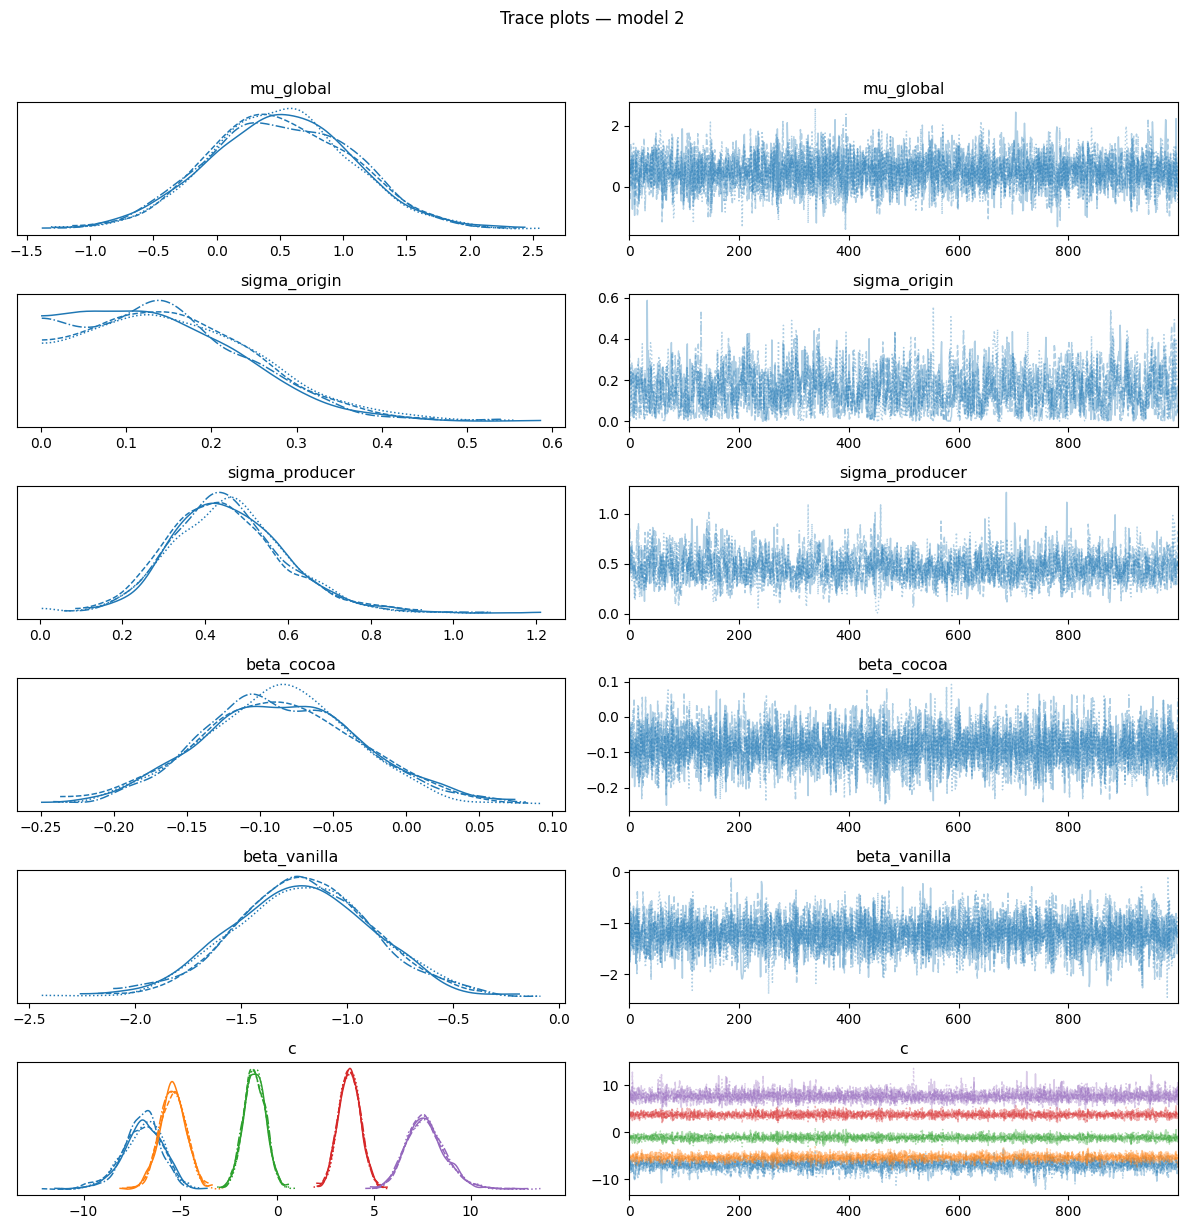

<Figure size 640x480 with 0 Axes>

In [103]:
print(fit2.diagnose())

idata2    = az.from_cmdstanpy(fit2)
summary2  = az.summary(idata2)
bad_rhat2 = summary2[summary2['r_hat'] > 1.01]
bad_ess2  = summary2[summary2['ess_bulk'] < 400]


if len(bad_rhat2) > 0:
    print(f"\nParameters with R-hat > 1.01: {len(bad_rhat2)}")
    print(bad_rhat2[['mean', 'sd', 'r_hat', 'ess_bulk']].head(20))

if len(bad_ess2) > 0:
    print(f"\nParameters with ESS < 400: {len(bad_ess2)}")
    print(bad_ess2[['mean', 'sd', 'r_hat', 'ess_bulk']].head(20))

# trace plots for scalar params only (vectors like beta_cocoa skipped here)
# az.plot_trace(idata2, var_names=["mu_global", "mu_beta_cocoa", 
#                                   "beta_vanilla", "sigma_origin",
#                                   "sigma_producer"])
az.plot_trace(idata2, var_names=["mu_global", "sigma_origin", "sigma_producer",
                                  "beta_cocoa", "beta_vanilla", "c"],
              coords={"c_dim_0": [0, 3, 7, 11, 15]})
plt.suptitle("Trace plots — model 2", y=1.02)
plt.tight_layout()
plt.show()
plt.suptitle("Trace plots - model 2", y=1.02)
plt.tight_layout()
plt.show()

Similarly to Model 1, non-fatal warnings occured at the start of the warmup phase but they did not affect the validity of the final posterior draws. The MCMC sampling process was completed successfully with no problems detected. The E-BFMI as well as R_hat and ESS for all parameters were satisfactory. 

Trace plots show fuzzy caterpillar traces indication satisfactory convergence for all parameters. The cutpoints show well-separated posteriors with good chain mixing. As observed in Model 1, cutpoints corresponding to the observed rating range (2.25–4) are sharply identified by the data, while the extreme cutpoints show wider posteriors.

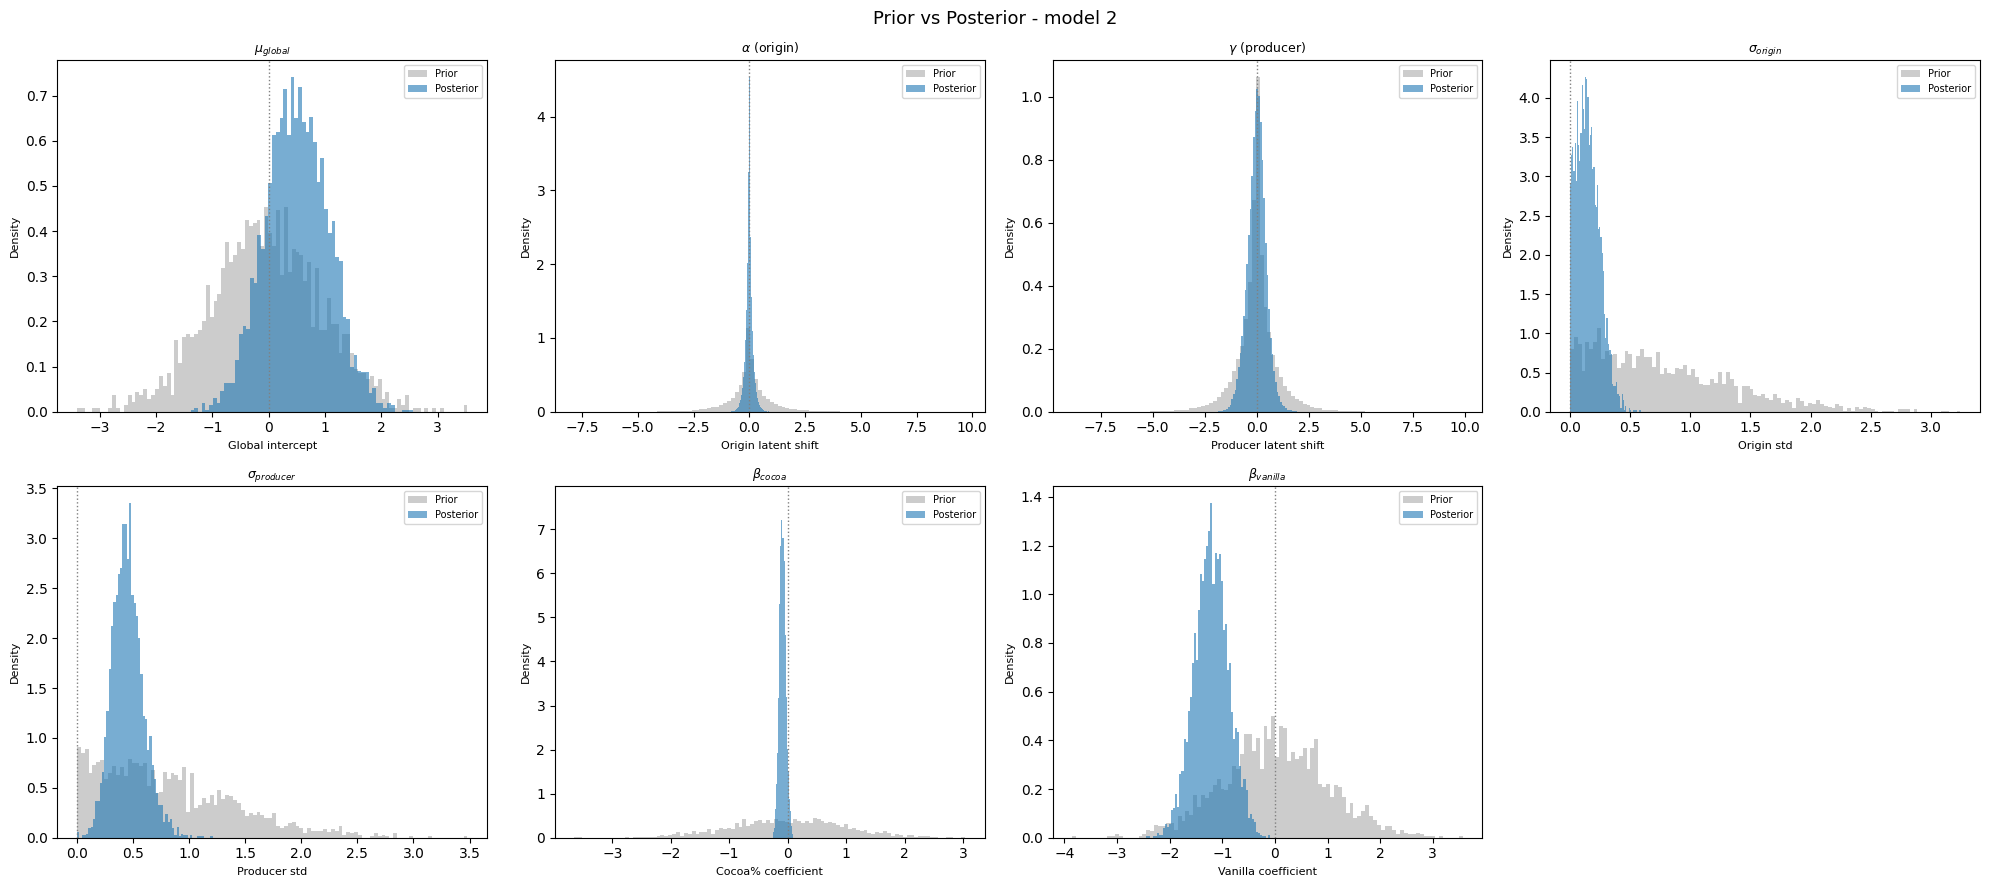

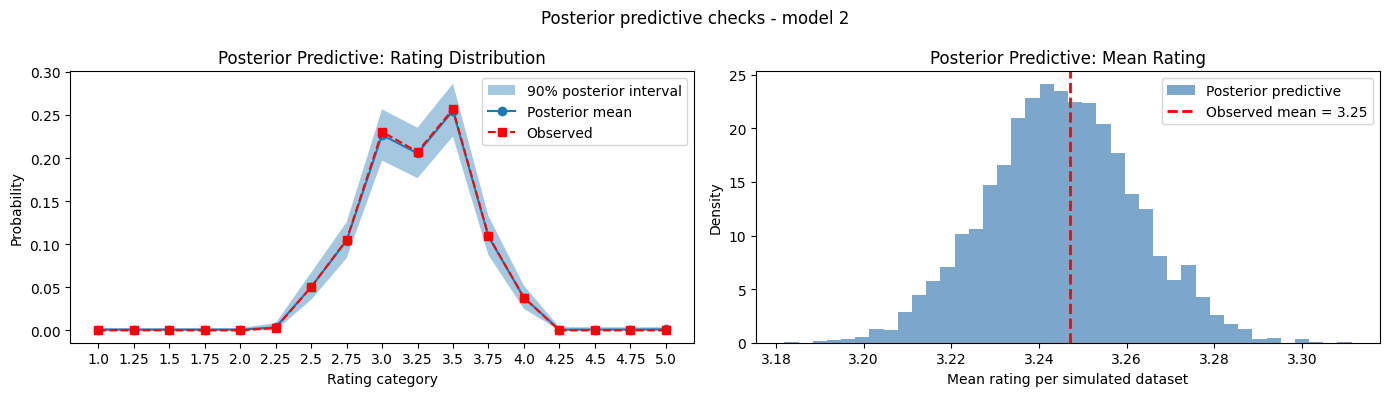

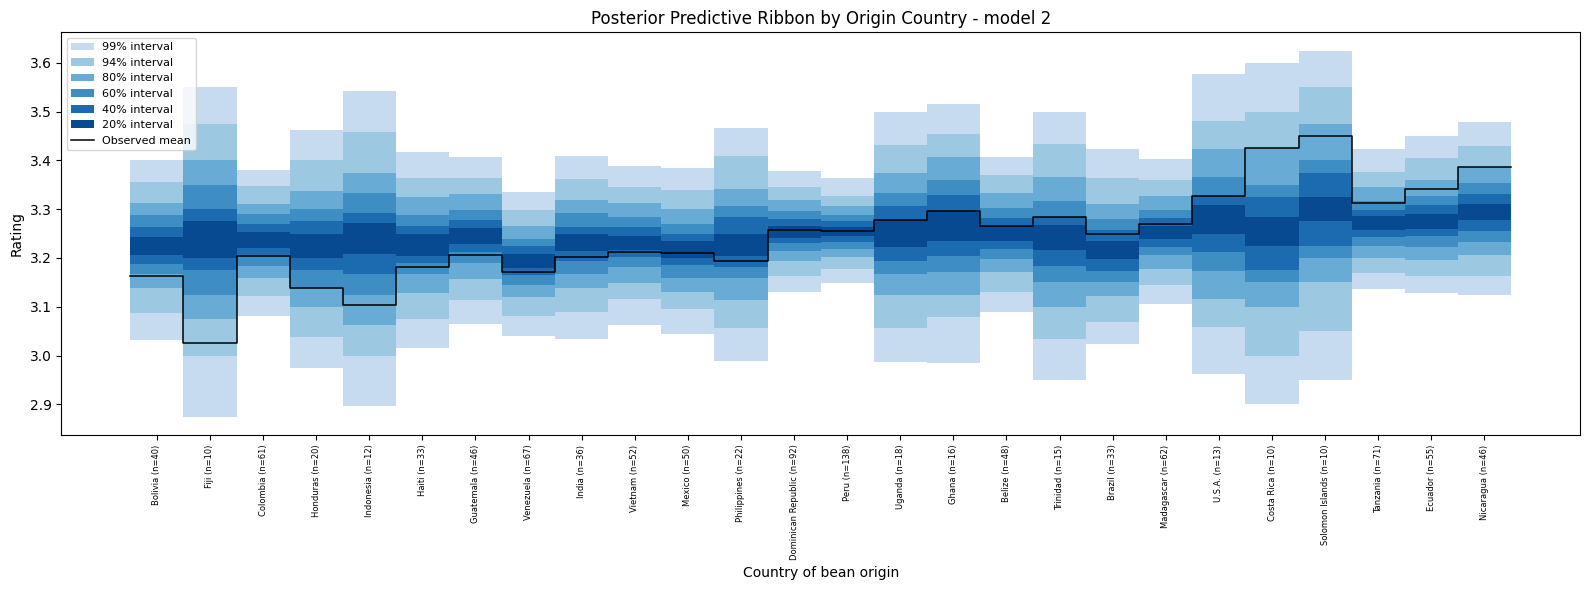

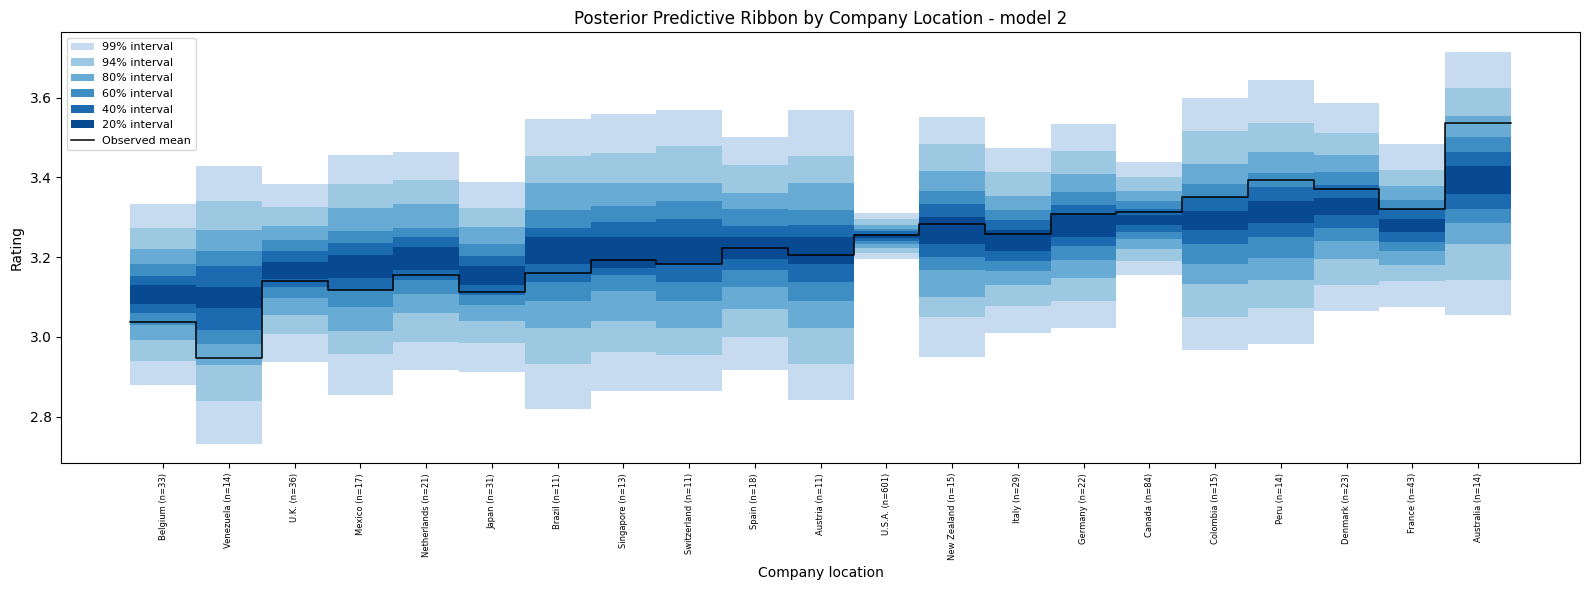

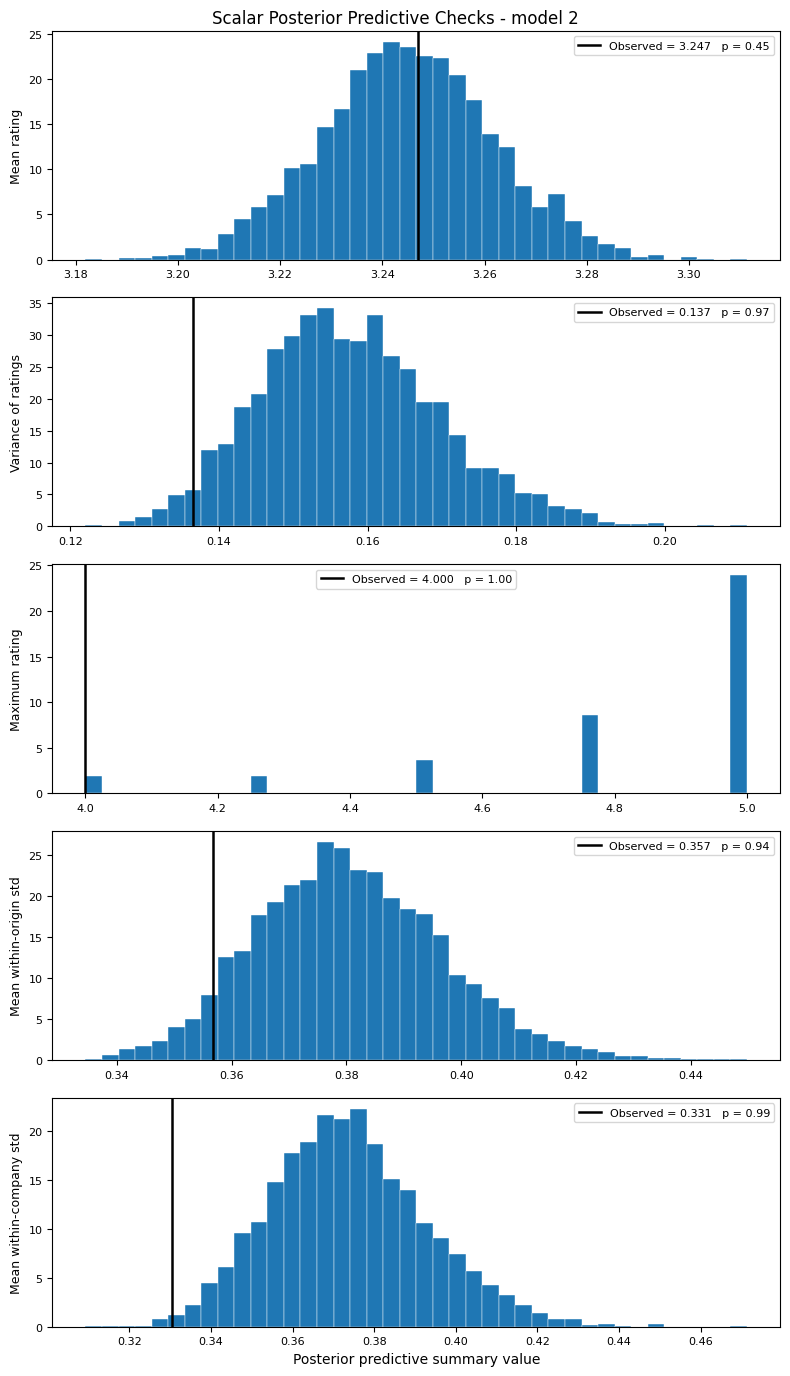

In [105]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()

panels = [
    (mu_global_samples2,       mu_global_prior2,       r"$\mu_{global}$",         "Global intercept"),
    (alpha_samples2.flatten(), alpha_prior2.flatten(),  r"$\alpha$ (origin)",      "Origin latent shift"),
    (gamma_samples2.flatten(), gamma_prior2.flatten(),  r"$\gamma$ (producer)",    "Producer latent shift"),
    (sigma_origin2,            sigma_origin_prior2,     r"$\sigma_{origin}$",      "Origin std"),
    (sigma_producer2,          sigma_prod_prior2,       r"$\sigma_{producer}$",    "Producer std"),
    (beta_cocoa_samples2,      beta_cocoa_prior2,       r"$\beta_{cocoa}$",        "Cocoa% coefficient"),
    (beta_vanilla_samples2,    beta_vanilla_prior2,     r"$\beta_{vanilla}$",      "Vanilla coefficient"),
]

for ax, (post, prior, title, xlabel) in zip(axes, panels):
    ax.hist(prior, bins=100, density=True, alpha=0.4, color="gray", label="Prior")
    ax.hist(post,  bins=60,  density=True, alpha=0.6, label="Posterior")
    ax.axvline(0, color="gray", ls=":", lw=1)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel(xlabel, fontsize=8)
    ax.set_ylabel("Density", fontsize=8)
    ax.legend(fontsize=7)

for ax in axes[len(panels):]:
    ax.set_visible(False)

plt.suptitle("Prior vs Posterior - model 2", fontsize=13)
plt.tight_layout()
plt.show()

# ── Posterior predictive: overall distribution ────────────
pred_counts2 = np.apply_along_axis(
    lambda x: np.bincount(x.astype(int) - 1, minlength=C), 1, rating_pred_post2
)
pred_probs2 = pred_counts2 / pred_counts2.sum(axis=1, keepdims=True)
obs_counts  = np.bincount(df['rating_id'].values.astype(int) - 1, minlength=C)
obs_probs   = obs_counts / obs_counts.sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.fill_between(range(1, C + 1),
                np.percentile(pred_probs2, 5,  axis=0),
                np.percentile(pred_probs2, 95, axis=0),
                alpha=0.4, label="90% posterior interval")
ax.plot(range(1, C + 1), pred_probs2.mean(axis=0), marker='o', label="Posterior mean")
ax.plot(range(1, C + 1), obs_probs, marker='s', color='red',
        ls='--', label="Observed")
ax.set_xlabel("Rating category"); ax.set_ylabel("Probability")
ax.set_title("Posterior Predictive: Rating Distribution")
xticks = all_possible_ratings
ax.set_xticks(range(1, C+1))
ax.set_xticklabels(xticks)
ax.legend()

ax = axes[1]
ax.hist(rating_pred_vals2.mean(axis=1), bins=40, density=True,
        alpha=0.7, color="steelblue", label="Posterior predictive")
ax.axvline(df["Rating"].mean(), color="red", lw=2, ls="--",
           label=f"Observed mean = {df['Rating'].mean():.2f}")
ax.set_xlabel("Mean rating per simulated dataset")
ax.set_ylabel("Density")
ax.set_title("Posterior Predictive: Mean Rating")
ax.legend()

plt.suptitle("Posterior predictive checks - model 2")
plt.tight_layout()
plt.show()

# ── Ribbon plot: bean origin ──────────────────────────────
current_df    = df.copy().reset_index(drop=True)
countries     = sorted(current_df["Country of Bean Origin"].unique())
country_idx   = {c: i + 1 for i, c in enumerate(countries)}
current_df["country_id"] = current_df["Country of Bean Origin"].map(country_idx)
counts_origin = current_df["Country of Bean Origin"].value_counts().to_dict()

mu_origin_total2 = mu_global_samples2[:, None] + alpha_samples2  # (draws, J)

results21 = pd.DataFrame({
    "country":     countries,
    "mu_mean":     mu_origin_total2.mean(axis=0),
    "mu_lower_94": np.percentile(mu_origin_total2, 3,  axis=0),
    "mu_upper_94": np.percentile(mu_origin_total2, 97, axis=0),
    "n_bars":      [counts_origin.get(c, 0) for c in countries],
}).sort_values("mu_mean", ascending=True).reset_index(drop=True)

obs_per_country2  = current_df.groupby("country_id")["Rating"].mean()
obs_sorted_orig2  = results21["country"].map(
    lambda c: obs_per_country2[country_idx[c]]
).values

J_sorted2  = len(results21)
x2         = np.arange(1, J_sorted2 + 1)
num_draws2 = rating_pred_vals2.shape[0]

post_pred_orig2 = np.zeros((num_draws2, J_sorted2))
for i, cname in enumerate(results21["country"]):
    idx = current_df[current_df["Country of Bean Origin"] == cname].index.values
    post_pred_orig2[:, i] = rating_pred_vals2[:, idx].mean(axis=1)

def step_edges(values, x):
    return (np.concatenate([x - 0.5, x[-1:] + 0.5]),
            np.concatenate([[values[0]], values]))

levels = [99, 94, 80, 60, 40, 20]
cmap   = matplotlib.colormaps["Blues"]
colors = [mcolors.to_hex(cmap(f)) for f in np.linspace(0.25, 0.9, len(levels))]

fig, ax = plt.subplots(figsize=(16, 6))
for lev, color in zip(levels, colors):
    lo = np.percentile(post_pred_orig2, (100 - lev) / 2,       axis=0)
    hi = np.percentile(post_pred_orig2, 100 - (100 - lev) / 2, axis=0)
    e, ls = step_edges(lo, x2); _, hs = step_edges(hi, x2)
    ax.fill_between(e, ls, hs, step="pre", color=color,
                    linewidth=0, label=f"{lev}% interval")

e, os_ = step_edges(obs_sorted_orig2, x2)
ax.step(e, os_, where="pre", color="black", linewidth=1.1, label="Observed mean")
ax.set_xticks(x2)
ax.set_xticklabels(
    [f"{r['country']} (n={r['n_bars']})" for _, r in results21.iterrows()],
    rotation=90, fontsize=6)
ax.set_xlabel("Country of bean origin"); ax.set_ylabel("Rating")
ax.set_title("Posterior Predictive Ribbon by Origin Country - model 2")
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()


# ── Ribbon plot: company location ─────────────────────────
company_locs  = sorted(current_df["Company Location"].unique())
company_idx   = {c: i + 1 for i, c in enumerate(company_locs)}
current_df["company_id"] = current_df["Company Location"].map(company_idx)
counts_company = current_df["Company Location"].value_counts().to_dict()

mu_company_total2 = mu_global_samples2[:, None] + gamma_samples2  # (draws, K)

results22 = pd.DataFrame({
    "company":     company_locs,
    "mu_mean":     mu_company_total2.mean(axis=0),
    "mu_lower_94": np.percentile(mu_company_total2, 3,  axis=0),
    "mu_upper_94": np.percentile(mu_company_total2, 97, axis=0),
    "n_bars":      [counts_company.get(c, 0) for c in company_locs],
}).sort_values("mu_mean", ascending=True).reset_index(drop=True)

obs_per_company2   = current_df.groupby("company_id")["Rating"].mean()
obs_sorted_comp2   = results22["company"].map(
    lambda c: obs_per_company2[company_idx[c]]
).values

K_sorted2 = len(results22)
x3        = np.arange(1, K_sorted2 + 1)

post_pred_comp2 = np.zeros((num_draws2, K_sorted2))
for i, cname in enumerate(results22["company"]):
    idx = current_df[current_df["Company Location"] == cname].index.values
    post_pred_comp2[:, i] = rating_pred_vals2[:, idx].mean(axis=1)

fig, ax = plt.subplots(figsize=(16, 6))
for lev, color in zip(levels, colors):
    lo = np.percentile(post_pred_comp2, (100 - lev) / 2,       axis=0)
    hi = np.percentile(post_pred_comp2, 100 - (100 - lev) / 2, axis=0)
    e, ls = step_edges(lo, x3); _, hs = step_edges(hi, x3)
    ax.fill_between(e, ls, hs, step="pre", color=color,
                    linewidth=0, label=f"{lev}% interval")

e, cs_ = step_edges(obs_sorted_comp2, x3)
ax.step(e, cs_, where="pre", color="black", linewidth=1.1, label="Observed mean")
ax.set_xticks(x3)
ax.set_xticklabels(
    [f"{r['company']} (n={r['n_bars']})" for _, r in results22.iterrows()],
    rotation=90, fontsize=6)
ax.set_xlabel("Company location"); ax.set_ylabel("Rating")
ax.set_title("Posterior Predictive Ribbon by Company Location - model 2")
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()


# ── Scalar posterior predictive checks ───────────────────
obs   = df["Rating"].values
y_rep = rating_pred_vals2

rep_mean = y_rep.mean(axis=1)
rep_var  = y_rep.var(axis=1)
rep_max  = y_rep.max(axis=1)

country_sds_rep = np.zeros((num_draws2, J_sorted2))
country_sds_obs = np.zeros(J_sorted2)
for i, cname in enumerate(results21["country"]):
    idx = current_df[current_df["Country of Bean Origin"] == cname].index.values
    if len(idx) > 1:
        country_sds_rep[:, i] = y_rep[:, idx].std(axis=1)
        country_sds_obs[i]    = obs[idx].std()

company_sds_rep = np.zeros((num_draws2, K_sorted2))
company_sds_obs = np.zeros(K_sorted2)
for i, cname in enumerate(results22["company"]):
    idx = current_df[current_df["Company Location"] == cname].index.values
    if len(idx) > 1:
        company_sds_rep[:, i] = y_rep[:, idx].std(axis=1)
        company_sds_obs[i]    = obs[idx].std()

checks = [
    (rep_mean,                        obs.mean(),                    "Mean rating"),
    (rep_var,                         obs.var(),                     "Variance of ratings"),
    (rep_max,                         obs.max(),                     "Maximum rating"),
    (country_sds_rep.mean(axis=1),    country_sds_obs.mean(),        "Mean within-origin std"),
    (company_sds_rep.mean(axis=1),    company_sds_obs.mean(),        "Mean within-company std"),
]

fig, axes = plt.subplots(5, 1, figsize=(8, 14))
for ax, (rep_stat, obs_stat, ylabel) in zip(axes, checks):
    ax.hist(rep_stat, bins=40, density=True, edgecolor="white", linewidth=0.3)
    p_val = np.mean(rep_stat >= obs_stat)
    ax.axvline(obs_stat, color="k", linewidth=1.8,
               label=f"Observed = {obs_stat:.3f}   p = {p_val:.2f}")
    ax.set_ylabel(ylabel, fontsize=9)
    ax.legend(fontsize=8)
    ax.tick_params(labelsize=8)

axes[-1].set_xlabel("Posterior predictive summary value", fontsize=10)
plt.suptitle("Scalar Posterior Predictive Checks - model 2", fontsize=12)
plt.tight_layout()
plt.show()

Prior vs posterior plot shows that $\mu_{global}$, $\alpha$, $\gamma$, $\sigma_{origin}$ and $\sigma_{producer}$ are consistent with Model 1. $\beta_{cocoa}$ is extremely tight around zero meaning the data provides almost no signal about cocoa% effect on rating. $\beta_{vanilla}$ posterior shifts notably negative (around −1), away from the zero-centered prior. This indicates that vanilla presence is associated with lower ratings and used to mask lower quality cocoa.

Similarly to Model 1 observed line tracks posterior mean closely across all categories, mean rating well-calibrated. Adding recipe predictors did not change predictive fit visibly. 

Ribbon plots show that observed means fall within posterior intervals for all groups, with appropriate width variation by group size. Recipe predictors did not meaningfully shift group-level predictions.

The scalar PPCs show identical overdispersion to Model 1, confirming that recipe predictors do not resolve the within-group variance issue.

## Model comapirson

Both models were compared using two information criteria: WAIC 
(Widely Applicable Information Criterion) and PSIS-LOO 
(Pareto-Smoothed Importance Sampling Leave-One-Out Cross-Validation), 
computed via ArviZ from the log-likelihood values stored in the 
generated quantities block of each model.

### WAIC

         rank    elpd_waic     p_waic  elpd_diff    weight         se  \
Model 2     0 -1919.418129  25.653007   0.000000  0.961532  18.784894   
Model 1     1 -1926.449533  24.060101   7.031405  0.038468  18.899532   

              dse  warning scale  
Model 2  0.000000     True   log  
Model 1  4.029668    False   log  


/usr/local/lib/python3.11/site-packages/arviz/stats/stats.py:1655: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(


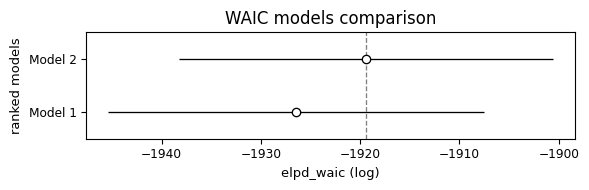

In [120]:
comp_dict = {
    "Model 1": fit1,
    "Model 2": fit2
}
comp_waic = az.compare(comp_dict, ic="waic")
print(comp_waic)

az.plot_compare(comp_waic)
plt.title("WAIC models comparison")
plt.tight_layout()
plt.show()

### PSIS - LOO

         rank     elpd_loo      p_loo  elpd_diff    weight         se  \
Model 2     0 -1919.488778  25.723656   0.000000  0.961271  18.788440   
Model 1     1 -1926.517066  24.127634   7.028288  0.038729  18.903394   

              dse  warning scale  
Model 2  0.000000    False   log  
Model 1  4.029772    False   log  


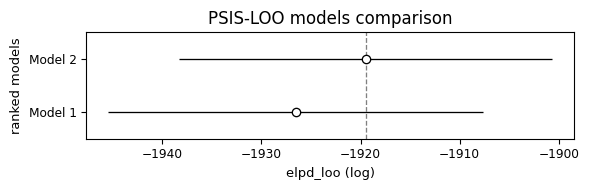

In [122]:
comp_loo = az.compare(comp_dict, ic="loo")
print(comp_loo)

az.plot_compare(comp_loo)
plt.title("PSIS-LOO models comparison")
plt.tight_layout()
plt.show()

### Model Comparison

Both WAIC and PSIS-LOO rank Model 2 above Model 1 with $elpd_diff \approx 7.0$ and $dse \approx 4.0$ resulting in ratio $\approx 1.75$, which is suggestive but below the threshold of 2 for a conclusive difference. WAIC reports a warning for Model 2 indicating high Pareto k values for some observations, suggesting the LOO approximation is less reliable and the apparent advantage of Model 2 should be interpreted with caution.


### Summary

Both models capture the dominant geographic structure of chocolate ratings well. Model 2 shows marginal improvement by adding bar recipe predictors, with beta_vanilla clearly negative which is consistent with industry practice of vanilla being used to mask lower-quality cocoa. However beta_cocoa concentrates near zero, providing no detectable signal. The improvement over Model 1 is suggestive rather than conclusive. Model 1 remains
a strong alternative. It is simpler, well calibrated and achieving comparable predictive performance using only geographic information
about bean origin and producer country.

## Sources
[1] : [Statista. (2026). Chocolate Confectionery - Worldwide: Market Insights & Forecast. Statista Consumer Market Outlook](https://www.statista.com/outlook/cmo/food/confectionery-snacks/confectionery/chocolate-confectionery/worldwide/?srsltid=AfmBOorxi7XFaZWdLCVjMUYGtJAp6RNSvUAMPQz5kLmDYZJz0M03wTzj)

[2] : [HTF Market Intelligence. (2026). Global Fine or Flavor Cocoa Market: Size, Industry Analysis, Trends, and Forecast to 2033. HTF Market Report.](https://www.htfmarketintelligence.com/report/global-fine-or-flavor-cocoa-market)

[3] : [Grand View Research. (2026). Chocolate Market Size, Share & Trends Analysis Report by Product (Traditional, Artificial), by Distribution Channel, and Segment Forecasts 2026 - 2033. Grand View Research.](https://www.grandviewresearch.com/industry-analysis/chocolate-market)

[4] : [Fanning, E., Eyres, G., Frew, R., & Kebede, B. (2023). Linking cocoa quality attributes to its origin using geographical indications. Food Control, 151, 109825.](https://www.sciencedirect.com/science/article/pii/S0956713523002256)

[5] : [Martin, Carla & Sampeck, Kathryn. (2015). The bitter and sweet of chocolate in Europe. Socio.hu. 37-60. 10.18030/socio.hu.2015en.37.](https://www.researchgate.net/publication/290471791_The_bitter_and_sweet_of_chocolate_in_Europe)

[6] : [Coracao Confections. (2026). Dark Chocolate: What 70%, 85%, and 99% Mean. Coracao Confections Blog.](https://www.coracaoconfections.com/blogs/news/a-dark-chocolate)